# Prominence-based Initial Guess Inspection
Visualise how the prominence peak finder initialises Gaussian components on real tomographic profiles.
Each plot shows: the raw profile, the smoothed profile, detected peaks (prominence-based), and the resulting initial Gaussian curves that are fed to the Adam optimiser.

## 1 · Config — point this to your tomogram

In [1]:
from pathlib import Path

# ── edit these ────────────────────────────────────────────────────────────────
TOMOGRAM_PATH = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset/data/tomogram_full_1000a16000a500a4000_1_Xparams_id2X.npy")
HEIGHT_RANGE  = (-20.0, 80.0)   # (h_min, h_max) in metres
N_GAUSSIANS   = 2               # number of Gaussian components to fit
N_PIXELS      = 30              # how many random pixels to inspect
SEED          = 42
PROMINENCE_FRAC = 0.05          # fraction of profile max used as prominence threshold
# ─────────────────────────────────────────────────────────────────────────────

## 2 · Imports & peak-init logic (copied from gpu_fitting.py)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks, peak_prominences


def prominence_init(profile_raw: np.ndarray, height_axis: np.ndarray, n_gaussians: int,
                    prominence_frac: float = 0.05):
    """
    Returns
    -------
    params      : (3*n_gaussians,) float32  — [amp, mu, sigma] × n_gaussians
    peaks_found : indices of peaks detected by find_peaks
    peaks_used  : indices of the n_gaussians peaks actually chosen
    props       : prominence properties dict from find_peaks
    smoothed    : smoothed profile used for detection
    """
    H           = len(height_axis)
    sigma_guess = float((height_axis[-1] - height_axis[0]) / (4.0 * n_gaussians))
    min_dist    = max(1, int(sigma_guess / (height_axis[1] - height_axis[0])))
    smoothed    = uniform_filter1d(profile_raw.astype(np.float32), size=5, mode="nearest")
    pmax        = smoothed.max()

    params      = np.zeros(3 * n_gaussians, dtype=np.float32)

    if pmax < 1e-10:
        idxs        = np.linspace(0, H - 1, n_gaussians, dtype=int)
        peaks_found = np.array([], dtype=int)
        props       = {}
        peaks_used  = idxs
    else:
        peaks, props = find_peaks(smoothed, prominence=pmax * prominence_frac, distance=min_dist)
        peaks_found  = peaks

        if len(peaks) >= n_gaussians:
            order      = np.argsort(props["prominences"])[::-1][:n_gaussians]
            idxs       = peaks[order]
        elif len(peaks) > 0:
            residual        = smoothed.copy()
            residual[peaks] = 0.0
            extra           = n_gaussians - len(peaks)
            extra_idxs      = []
            for _ in range(extra):
                ei = int(np.argmax(residual))
                extra_idxs.append(ei)
                lo = max(0, ei - min_dist)
                hi = min(H, ei + min_dist + 1)
                residual[lo:hi] = 0.0
            idxs = np.concatenate([peaks, np.array(extra_idxs, dtype=int)])
        else:
            idxs = np.linspace(0, H - 1, n_gaussians, dtype=int)

        peaks_used = idxs

    for g, idx in enumerate(idxs[:n_gaussians]):
        params[g*3 + 0] = max(float(smoothed[idx]), 1e-10)
        params[g*3 + 1] = float(height_axis[idx])
        params[g*3 + 2] = sigma_guess

    return params, peaks_found, peaks_used, props, smoothed


def eval_gaussian_mix(height_axis, params, n_gaussians):
    """Evaluate the sum of Gaussians given flat params array."""
    result = np.zeros_like(height_axis, dtype=np.float64)
    for g in range(n_gaussians):
        amp, mu, sig = params[g*3], params[g*3+1], params[g*3+2]
        sig = max(sig, 1e-6)
        result += amp * np.exp(-((height_axis - mu)**2) / (2 * sig**2))
    return result


print("Functions loaded.")

Functions loaded.


## 3 · Load tomogram & sample random pixels

In [3]:
tomo  = np.load(TOMOGRAM_PATH, mmap_mode="r", allow_pickle=False)
H, Az, R = tomo.shape
height_axis = np.linspace(HEIGHT_RANGE[0], HEIGHT_RANGE[1], H, dtype=np.float32)

print(f"Tomogram shape : H={H}  Az={Az}  R={R}")
print(f"Height axis    : {height_axis[0]:.1f} → {height_axis[-1]:.1f} m  (step={height_axis[1]-height_axis[0]:.3f} m)")

rng     = np.random.default_rng(SEED)
az_idx  = rng.integers(0, Az, N_PIXELS)
r_idx   = rng.integers(0, R,  N_PIXELS)
profiles_raw = np.abs(tomo[:, az_idx, r_idx]).T.astype(np.float32)  # (N_PIXELS, H)
print(f"Sampled {N_PIXELS} pixels.")

Tomogram shape : H=150  Az=15000  R=3500
Height axis    : -20.0 → 80.0 m  (step=0.671 m)
Sampled 30 pixels.


## 4 · Run prominence init on all sampled pixels

In [4]:
results = []
for i in range(N_PIXELS):
    params, peaks_found, peaks_used, props, smoothed = prominence_init(
        profiles_raw[i], height_axis, N_GAUSSIANS, PROMINENCE_FRAC
    )
    results.append(dict(
        raw         = profiles_raw[i],
        smoothed    = smoothed,
        params      = params,
        peaks_found = peaks_found,
        peaks_used  = peaks_used,
        props       = props,
        az          = az_idx[i],
        r           = r_idx[i],
    ))

print("Done.")

Done.


## 5 · Grid visualisation — profile + peaks + initial Gaussian components

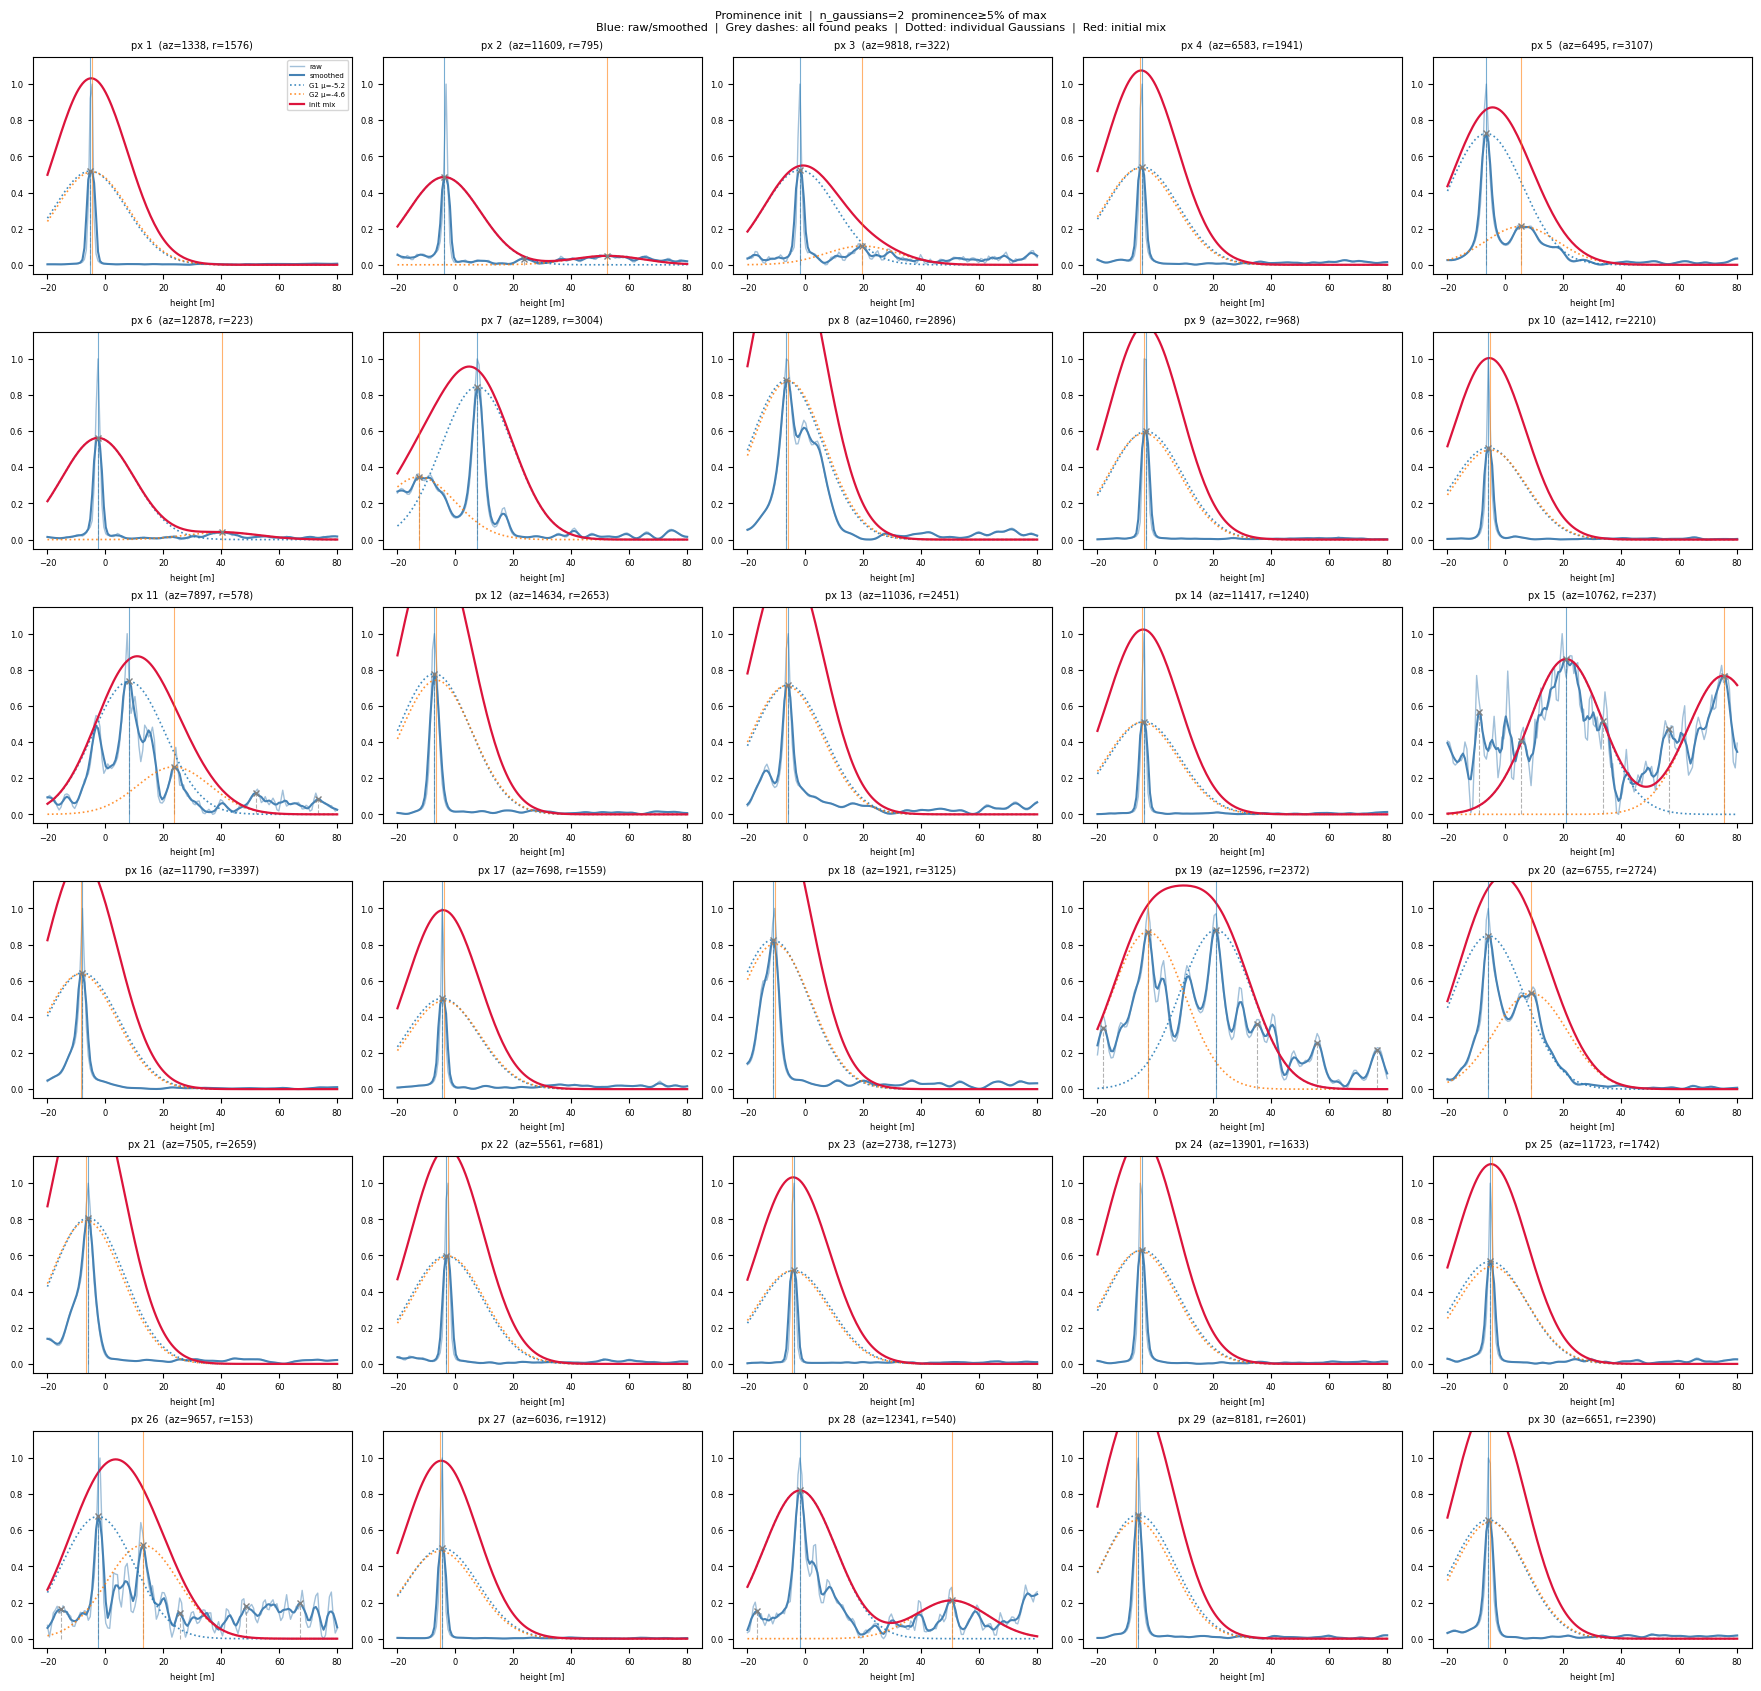

In [5]:
COLS   = 5
ROWS   = int(np.ceil(N_PIXELS / COLS))
COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 2.8), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, res in enumerate(results):
    ax  = axes[i]
    h   = height_axis
    raw = res["raw"]
    smo = res["smoothed"]
    par = res["params"]
    pf  = res["peaks_found"]
    pu  = res["peaks_used"]

    # normalise for display
    norm = raw.max() if raw.max() > 1e-10 else 1.0

    ax.plot(h, raw / norm,       color="steelblue",  lw=1.0, alpha=0.5, label="raw")
    ax.plot(h, smo / norm,       color="steelblue",  lw=1.5, label="smoothed")

    # all prominence-detected peaks (grey ticks)
    if len(pf):
        ax.vlines(h[pf], 0, smo[pf] / norm, color="grey", lw=0.8, linestyle="--", alpha=0.6)
        ax.plot(h[pf], smo[pf] / norm, "x", color="grey", ms=5, zorder=3)

    # initial Gaussian components
    mix = np.zeros_like(h, dtype=np.float64)
    for g in range(N_GAUSSIANS):
        amp, mu, sig = par[g*3], par[g*3+1], par[g*3+2]
        sig = max(sig, 1e-6)
        comp = amp * np.exp(-((h - mu)**2) / (2 * sig**2)) / norm
        mix += comp
        ax.plot(h, comp, color=COLORS[g % len(COLORS)], lw=1.2, linestyle=":", alpha=0.85, label=f"G{g+1} μ={mu:.1f}")

    ax.plot(h, mix, color="crimson", lw=1.6, label="init mix")

    # mark chosen peaks
    for g, idx in enumerate(pu[:N_GAUSSIANS]):
        ax.axvline(h[idx], color=COLORS[g % len(COLORS)], lw=0.8, alpha=0.6)

    ax.set_title(f"px {i+1}  (az={res['az']}, r={res['r']})", fontsize=7)
    ax.set_xlabel("height [m]", fontsize=6)
    ax.tick_params(labelsize=6)
    ax.set_ylim(-0.05, 1.15)
    if i == 0:
        ax.legend(fontsize=5, loc="upper right")

# hide unused axes
for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Prominence init  |  n_gaussians={N_GAUSSIANS}  prominence≥{PROMINENCE_FRAC*100:.0f}% of max\n"
    f"Blue: raw/smoothed  |  Grey dashes: all found peaks  |  Dotted: individual Gaussians  |  Red: initial mix",
    fontsize=8
)
plt.show()

## 6 · Prominence threshold sweep — see how many peaks are found at different thresholds

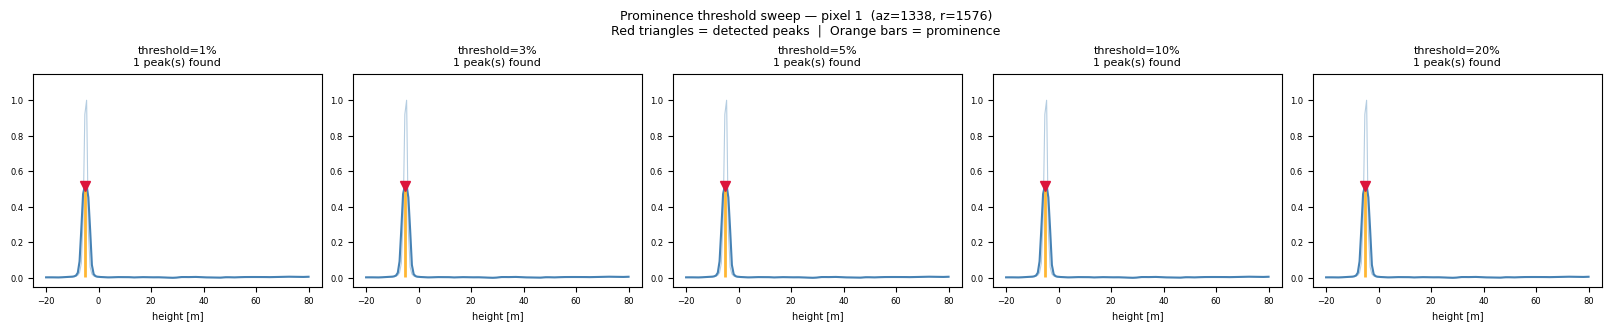

In [6]:
# Pick a single interesting pixel (change index to explore others)
PIXEL_IDX = 0

thresholds = [0.01, 0.03, 0.05, 0.10, 0.20]
res0       = results[PIXEL_IDX]
raw0       = res0["raw"]
smo0       = res0["smoothed"]
norm0      = raw0.max() if raw0.max() > 1e-10 else 1.0
sigma_guess = float((height_axis[-1] - height_axis[0]) / (4.0 * N_GAUSSIANS))
min_dist    = max(1, int(sigma_guess / (height_axis[1] - height_axis[0])))

fig, axes = plt.subplots(1, len(thresholds), figsize=(len(thresholds) * 3.2, 3.2), constrained_layout=True)

for ax, thr in zip(axes, thresholds):
    peaks, props = find_peaks(smo0, prominence=smo0.max() * thr, distance=min_dist)
    prom_vals    = props.get("prominences", np.array([]))

    ax.plot(height_axis, smo0 / norm0, color="steelblue", lw=1.5)
    ax.plot(height_axis, raw0 / norm0, color="steelblue", lw=0.8, alpha=0.4)

    if len(peaks):
        ax.plot(height_axis[peaks], smo0[peaks] / norm0, "v", color="crimson", ms=7, zorder=5)
        # draw prominence bars
        left_bases  = props.get("left_bases",  peaks)
        right_bases = props.get("right_bases", peaks)
        for pk, lb, rb, pv in zip(peaks, left_bases, right_bases, prom_vals):
            base_h = max(smo0[lb], smo0[rb])
            ax.vlines(height_axis[pk], base_h / norm0, smo0[pk] / norm0,
                      color="orange", lw=2, alpha=0.8)

    ax.set_title(f"threshold={thr*100:.0f}%\n{len(peaks)} peak(s) found", fontsize=8)
    ax.set_xlabel("height [m]", fontsize=7)
    ax.set_ylim(-0.05, 1.15)
    ax.tick_params(labelsize=6)

fig.suptitle(f"Prominence threshold sweep — pixel {PIXEL_IDX+1}  (az={res0['az']}, r={res0['r']})\n"
             "Red triangles = detected peaks  |  Orange bars = prominence", fontsize=9)
plt.show()

## 7 · Stats — how often does the init find exactly N peaks across all sampled pixels?

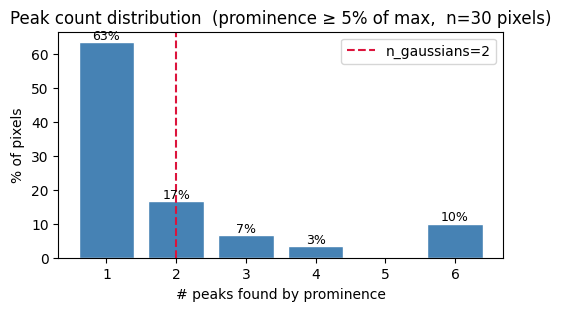


Exact match (2 peaks found) : 16.7%
Fewer peaks found (residual fallback)   : 63.3%
More peaks found  (top-k selected)      : 20.0%


In [7]:
n_found = np.array([len(r["peaks_found"]) for r in results])
vals, counts = np.unique(n_found, return_counts=True)

fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
bars = ax.bar(vals, counts / N_PIXELS * 100, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.0f%%", fontsize=9)
ax.axvline(N_GAUSSIANS, color="crimson", lw=1.5, linestyle="--", label=f"n_gaussians={N_GAUSSIANS}")
ax.set_xlabel("# peaks found by prominence")
ax.set_ylabel("% of pixels")
ax.set_title(f"Peak count distribution  (prominence ≥ {PROMINENCE_FRAC*100:.0f}% of max,  n={N_PIXELS} pixels)")
ax.legend()
plt.show()

print(f"\nExact match ({N_GAUSSIANS} peaks found) : {(n_found == N_GAUSSIANS).mean()*100:.1f}%")
print(f"Fewer peaks found (residual fallback)   : {(n_found < N_GAUSSIANS).mean()*100:.1f}%")
print(f"More peaks found  (top-k selected)      : {(n_found > N_GAUSSIANS).mean()*100:.1f}%")

## 8 · LR schedule visualisation — warm-up + cosine decay

See how the learning rate evolves for different `lr`, `warmup_steps`, and `adam_steps` combinations before running the full fit.

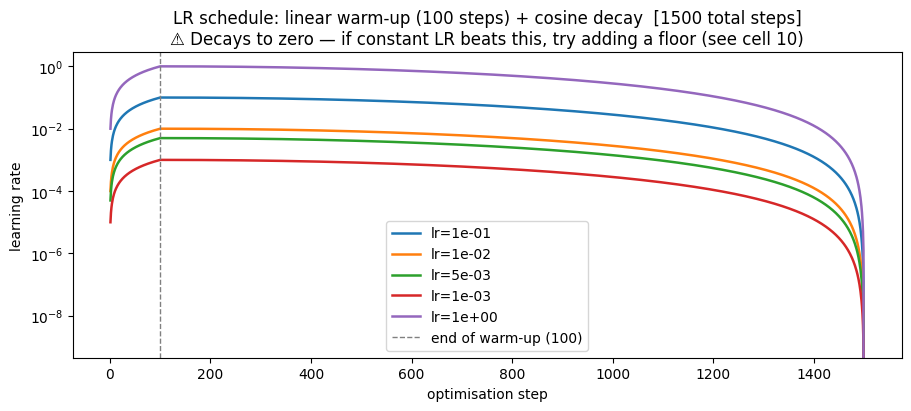

In [8]:
# ── LR schedule config — edit these and re-run ────────────────────────────────
LR_CANDIDATES      = [1e-1, 1e-2, 5e-3, 1e-3, 1]   # peak learning rates to compare
ADAM_STEPS         = 1500                          # total optimisation steps
WARMUP_STEPS       = 100                           # linear warm-up duration
# ─────────────────────────────────────────────────────────────────────────────

def lr_schedule(t: np.ndarray, lr_max: float, n_steps: int, warmup: int) -> np.ndarray:
    """Vectorised warm-up + cosine decay (mirrors the JAX implementation)."""
    warmup_lr = lr_max * t / max(warmup, 1)
    progress  = np.clip((t - warmup) / max(n_steps - warmup, 1), 0.0, 1.0)
    cosine_lr = lr_max * 0.5 * (1.0 + np.cos(np.pi * progress))
    return np.where(t < warmup, warmup_lr, cosine_lr)

steps = np.arange(1, ADAM_STEPS + 1)

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for lr_max in LR_CANDIDATES:
    lrs = lr_schedule(steps, lr_max, ADAM_STEPS, WARMUP_STEPS)
    ax.plot(steps, lrs, lw=1.8, label=f"lr={lr_max:.0e}")

ax.axvline(WARMUP_STEPS, color="grey", lw=1, linestyle="--", label=f"end of warm-up ({WARMUP_STEPS})")
ax.set_xlabel("optimisation step")
ax.set_ylabel("learning rate")
ax.set_title(f"LR schedule: linear warm-up ({WARMUP_STEPS} steps) + cosine decay  [{ADAM_STEPS} total steps]\n"
             f"⚠ Decays to zero — if constant LR beats this, try adding a floor (see cell 10)")
ax.legend()
ax.set_yscale("log")
plt.show()

## 9 · Warm-up length sweep — effect on early steps

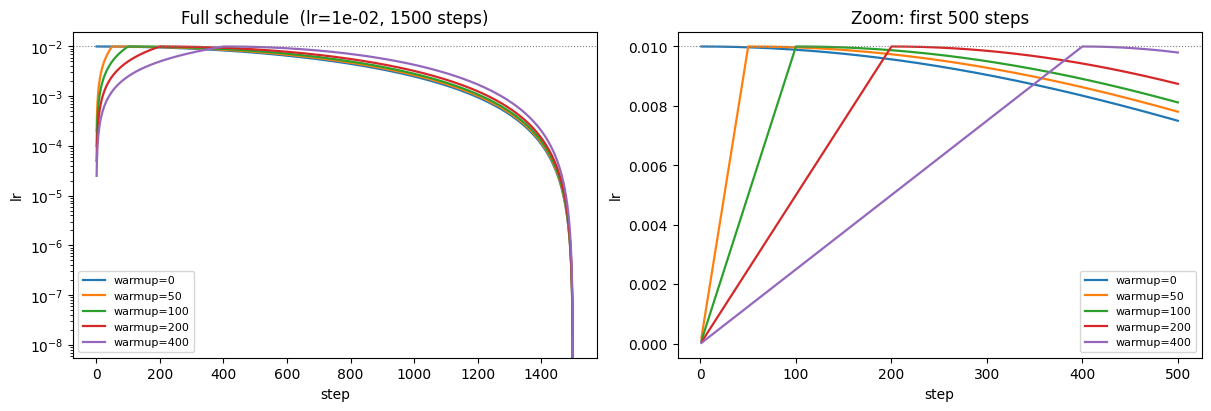

In [9]:
WARMUP_CANDIDATES = [0, 50, 100, 200, 400]
FIXED_LR          = 1e-2   # fix lr, sweep warmup

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# left: full schedule
for w in WARMUP_CANDIDATES:
    lrs = lr_schedule(steps, FIXED_LR, ADAM_STEPS, w)
    axes[0].plot(steps, lrs, lw=1.6, label=f"warmup={w}")
axes[0].axhline(FIXED_LR, color="grey", lw=0.8, linestyle=":")
axes[0].set_xlabel("step"); axes[0].set_ylabel("lr"); axes[0].set_yscale("log")
axes[0].set_title(f"Full schedule  (lr={FIXED_LR:.0e}, {ADAM_STEPS} steps)")
axes[0].legend(fontsize=8)

# right: zoom on the first 500 steps to see warm-up detail
zoom = steps[steps <= 500]
for w in WARMUP_CANDIDATES:
    lrs = lr_schedule(zoom, FIXED_LR, ADAM_STEPS, w)
    axes[1].plot(zoom, lrs, lw=1.6, label=f"warmup={w}")
axes[1].axhline(FIXED_LR, color="grey", lw=0.8, linestyle=":")
axes[1].set_xlabel("step"); axes[1].set_ylabel("lr")
axes[1].set_title("Zoom: first 500 steps")
axes[1].legend(fontsize=8)

plt.show()

## 10 · Mini fit on a single pixel — compare constant LR vs. scheduled LR

Run a small numpy Adam loop on one real pixel so you can see the loss curve with and without the schedule.

Initial params (normalised):
  G1: amp=0.519  mu=-5.23m  sigma=12.50m
  G2: amp=0.514  mu=-4.56m  sigma=12.50m

free μ+amp  final MSE = 0.011654
  G1: amp=0.004  mu=-5.53m  sigma=10.65m
  G1: amp=0.004  mu=-5.53m  sigma=10.65m
  G2: amp=0.001  mu=-5.26m  sigma=11.19m
  G2: amp=0.001  mu=-5.26m  sigma=11.19m

frozen μ    final MSE = 0.011593
  G1: amp=0.005  mu=-5.23m  sigma=10.34m
  G1: amp=0.005  mu=-5.23m  sigma=10.34m
  G2: amp=0.000  mu=-4.56m  sigma=11.44m
  G2: amp=0.000  mu=-4.56m  sigma=11.44m

σ only      final MSE = 0.000371
  G1: amp=0.027  mu=-5.23m  sigma=0.70m
  G1: amp=0.027  mu=-5.23m  sigma=0.70m
  G2: amp=0.027  mu=-4.56m  sigma=0.61m
  G2: amp=0.027  mu=-4.56m  sigma=0.61m


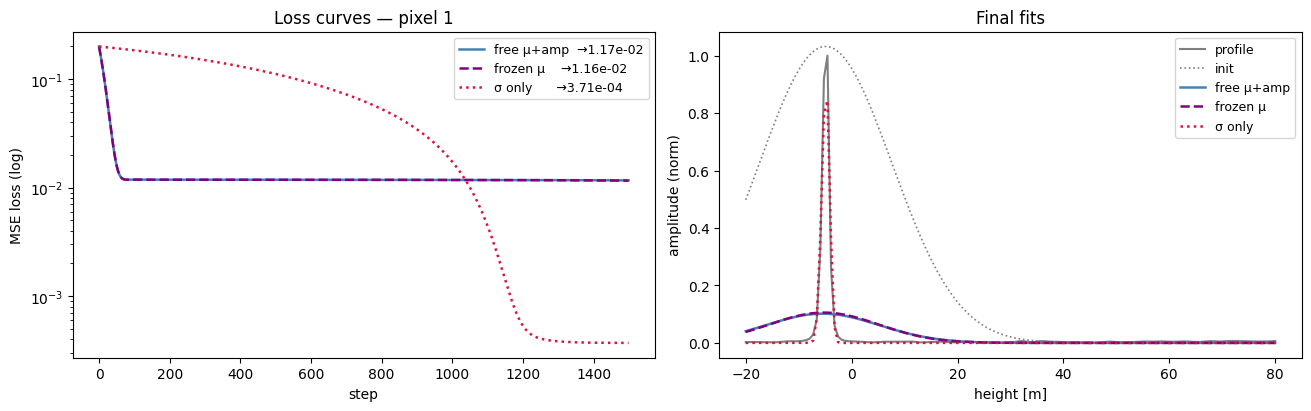

In [10]:
FIT_PIXEL_IDX = 0    # which pixel from `results` to fit
FIT_STEPS     = 1500
FIT_LR        = 1e-2
FIT_WARMUP    = 100
B1, B2, EPS   = 0.9, 0.999, 1e-8


def build_bounds(height_axis, n_gaussians):
    h_min, h_max = float(height_axis[0]), float(height_axis[-1])
    span         = h_max - h_min
    lo, hi       = [], []
    for _ in range(n_gaussians):
        lo += [0.0, h_min, 0.0     ]
        hi += [1.0, h_max, span / 2]
    return np.array(lo, dtype=np.float64), np.array(hi, dtype=np.float64)


def mse_loss_and_grad(params, profile, h):
    n_g  = len(params) // 3
    pred = np.zeros_like(h)
    for g in range(n_g):
        a, mu, sig = params[g*3], params[g*3+1], max(params[g*3+2], 1e-6)
        d = h - mu; e = np.exp(-(d**2) / (2*sig**2))
        pred += a * e
    residual = pred - profile
    loss     = float(np.mean(residual**2))
    grad     = np.zeros_like(params)
    for g in range(n_g):
        a, mu, sig = params[g*3], params[g*3+1], max(params[g*3+2], 1e-6)
        d = h - mu; e = np.exp(-(d**2) / (2*sig**2))
        scale = 2 * residual / len(h)
        grad[g*3]   = np.sum(scale * e)
        grad[g*3+1] = np.sum(scale * a * e * (d / sig**2))
        grad[g*3+2] = np.sum(scale * a * e * (d**2 / sig**3))
    return loss, grad


def adam_run(init_params, profile, h, n_steps, lr_max, lower, upper,
             b1=B1, b2=B2, eps=EPS, freeze_means=False, freeze_amps=False):
    """Adam optimiser.
    freeze_means=True  : μ locked exactly at init values.
    freeze_amps=True   : amplitudes locked exactly at init values.
    """
    p        = np.clip(init_params.copy().astype(np.float64), lower, upper)
    mu_init  = p[1::3].copy()
    amp_init = p[0::3].copy()
    m        = np.zeros_like(p)
    v        = np.zeros_like(p)
    losses   = []
    for t in range(1, n_steps + 1):
        loss, g = mse_loss_and_grad(p, profile, h)
        if freeze_means:
            g[1::3] = 0.0          # kill mean gradients
        if freeze_amps:
            g[0::3] = 0.0          # kill amplitude gradients
        losses.append(loss)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        p = p - lr_max * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
        p = np.clip(p, lower, upper)
        if freeze_means:
            p[1::3] = mu_init      # hard-reset means after every step
        if freeze_amps:
            p[0::3] = amp_init     # hard-reset amplitudes after every step
    return p, np.array(losses)


# ── Setup ─────────────────────────────────────────────────────────────────────
res_px    = results[FIT_PIXEL_IDX]
profile   = res_px["raw"].astype(np.float64)
norm      = profile.max() if profile.max() > 1e-10 else 1.0
profile_n = profile / norm
h64       = height_axis.astype(np.float64)

init_p = res_px["params"].astype(np.float64).copy()
for g in range(N_GAUSSIANS):
    init_p[g*3] /= norm

lower_b, upper_b = build_bounds(height_axis, N_GAUSSIANS)

print("Initial params (normalised):")
for g in range(N_GAUSSIANS):
    print(f"  G{g+1}: amp={init_p[g*3]:.3f}  mu={init_p[g*3+1]:.2f}m  sigma={init_p[g*3+2]:.2f}m")

# ── Run both variants ─────────────────────────────────────────────────────────
p_free,   losses_free   = adam_run(init_p, profile_n, h64, FIT_STEPS, FIT_LR, lower_b, upper_b, freeze_means=False, freeze_amps=False)
p_frozen, losses_frozen = adam_run(init_p, profile_n, h64, FIT_STEPS, FIT_LR, lower_b, upper_b, freeze_means=True,  freeze_amps=False)
p_sigonly, losses_sigonly = adam_run(init_p, profile_n, h64, FIT_STEPS, FIT_LR, lower_b, upper_b, freeze_means=True, freeze_amps=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].semilogy(losses_free,    color="steelblue", lw=1.8, label=f"free μ+amp  →{losses_free[-1]:.2e}")
axes[0].semilogy(losses_frozen,  color="purple",    lw=1.8, label=f"frozen μ    →{losses_frozen[-1]:.2e}",  ls="--")
axes[0].semilogy(losses_sigonly, color="crimson",   lw=1.8, label=f"σ only      →{losses_sigonly[-1]:.2e}", ls=":")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss (log)")
axes[0].set_title(f"Loss curves — pixel {FIT_PIXEL_IDX+1}")
axes[0].legend(fontsize=9)

# final fits
axes[1].plot(h64, profile_n, color="black", lw=1.5, alpha=0.5, label="profile")
axes[1].plot(h64, eval_gaussian_mix(h64, init_p, N_GAUSSIANS), ":", color="grey", lw=1.2, label="init")
p_free_plot  = p_free.copy();   p_free_plot[0::3]   *= norm
p_froz_plot  = p_frozen.copy(); p_froz_plot[0::3]   *= norm
p_sigo_plot  = p_sigonly.copy(); p_sigo_plot[0::3]   *= norm
axes[1].plot(h64, eval_gaussian_mix(h64, p_free_plot,  N_GAUSSIANS) / norm,
             color="steelblue", lw=1.8, label="free μ+amp")
axes[1].plot(h64, eval_gaussian_mix(h64, p_froz_plot,  N_GAUSSIANS) / norm,
             color="purple",    lw=1.8, ls="--", label="frozen μ")
axes[1].plot(h64, eval_gaussian_mix(h64, p_sigo_plot,  N_GAUSSIANS) / norm,
             color="crimson",   lw=1.8, ls=":",  label="σ only")
axes[1].set_title("Final fits"); axes[1].legend(fontsize=9)
axes[1].set_xlabel("height [m]"); axes[1].set_ylabel("amplitude (norm)")
axes[1].set_title("Final fits"); axes[1].legend(fontsize=9)

for label, p_res, losses_res in [
        ("free μ+amp", p_free,   losses_free),
        ("frozen μ  ", p_frozen, losses_frozen),
        ("σ only    ", p_sigonly, losses_sigonly),
]:

    print(f"\n{label}  final MSE = {losses_res[-1]:.6f}")
    for g in range(N_GAUSSIANS):
        print(f"  G{g+1}: amp={p_res[g*3]*norm:.3f}  mu={p_res[g*3+1]:.2f}m  sigma={p_res[g*3+2]:.2f}m")
        print(f"  G{g+1}: amp={p_res[g*3]*norm:.3f}  mu={p_res[g*3+1]:.2f}m  sigma={p_res[g*3+2]:.2f}m")

## 11 · Diagnose component collapse — track mean (μ) trajectories during fit

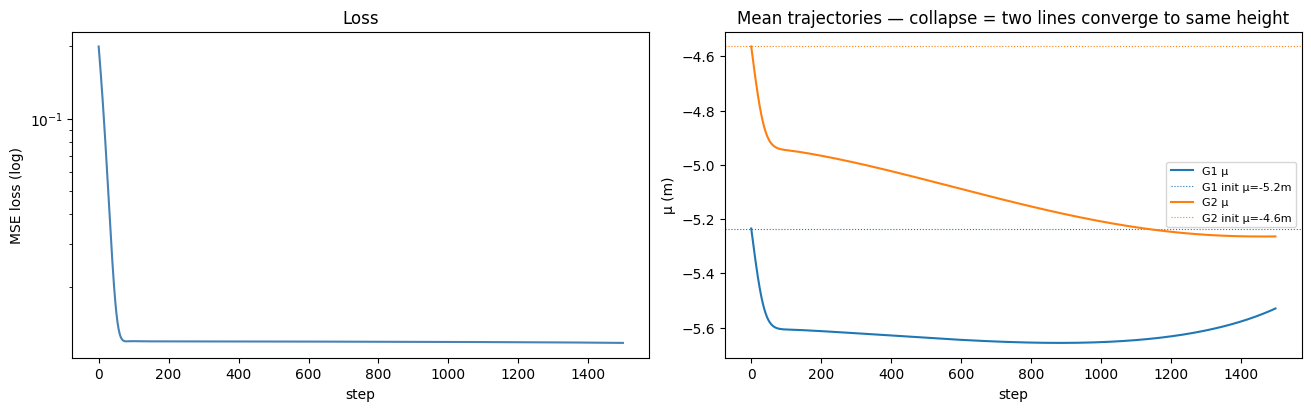

Final means:
  G1: init μ=-5.23m  →  final μ=-5.53m
  G2: init μ=-4.56m  →  final μ=-5.26m


In [11]:
def adam_run_tracked(init_params, profile, h, n_steps, lr_max, lower, upper,
                     b1=B1, b2=B2, eps=EPS, sep_penalty=0.0):
    """Same as adam_run (constant LR) but records mu values every step."""
    p      = np.clip(init_params.copy().astype(np.float64), lower, upper)
    m      = np.zeros_like(p); v = np.zeros_like(p)
    losses = []
    n_g    = len(p) // 3
    mu_history = [[] for _ in range(n_g)]   # one list per Gaussian

    for t in range(1, n_steps + 1):
        loss, g = mse_loss_and_grad(p, profile, h)

        # optional separation penalty: push means apart
        if sep_penalty > 0.0 and n_g > 1:
            mus = p[1::3]
            for i in range(n_g):
                for j in range(n_g):
                    if i != j:
                        diff = mus[i] - mus[j]
                        loss += sep_penalty * np.exp(-(diff**2) / (2 * 5.0**2))
                        grad_val = sep_penalty * np.exp(-(diff**2) / (2 * 5.0**2)) * (-diff / 25.0)
                        g[i*3+1] += grad_val
                        g[j*3+1] -= grad_val

        losses.append(loss)
        for gi in range(n_g):
            mu_history[gi].append(p[gi*3+1])

        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        p = p - lr_max * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
        p = np.clip(p, lower, upper)

    return p, np.array(losses), [np.array(mh) for mh in mu_history]


p_track, losses_track, mu_hist = adam_run_tracked(
    init_p, profile_n, h64, FIT_STEPS, FIT_LR, lower_b, upper_b
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

# left: loss
axes[0].semilogy(losses_track, color="steelblue", lw=1.5)
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss (log)")
axes[0].set_title("Loss")

# right: mu trajectories — this reveals collapse
for g, mh in enumerate(mu_hist):
    axes[1].plot(mh, lw=1.5, color=COLORS[g % len(COLORS)], label=f"G{g+1} μ")
    axes[1].axhline(init_p[g*3+1], color=COLORS[g % len(COLORS)], lw=0.8, linestyle=":",
                    label=f"G{g+1} init μ={init_p[g*3+1]:.1f}m")

axes[1].set_xlabel("step"); axes[1].set_ylabel("μ (m)")
axes[1].set_title("Mean trajectories — collapse = two lines converge to same height")
axes[1].legend(fontsize=8)

plt.show()
print("Final means:")
for g in range(N_GAUSSIANS):
    print(f"  G{g+1}: init μ={init_p[g*3+1]:.2f}m  →  final μ={p_track[g*3+1]:.2f}m")

## 12 · Free-order σ-only fit — Adam fits only σ, amplitudes & means frozen, complexity penalty on number of active Gaussians

Starting from the prominence init, run Adam with amplitudes and means **frozen at their initial values**.  
Only σ is optimised.  
A **complexity penalty** (`lambda_k`) discourages keeping many Gaussians active by penalising the sum of amplitudes (soft proxy for model order).  
The best model order `K` (1 … `K_MAX`) is selected by the **penalised loss** after fitting.


K=1  final MSE=0.034237  complexity_cost=0.002593  penalised=0.036829
K=2  final MSE=0.000371  complexity_cost=0.005164  penalised=0.005535
K=3  final MSE=0.000362  complexity_cost=0.005196  penalised=0.005558
K=4  final MSE=0.000363  complexity_cost=0.005226  penalised=0.005589
K=5  final MSE=0.000359  complexity_cost=0.005260  penalised=0.005619

→ Best K = 2  (lowest penalised loss = 0.005535)


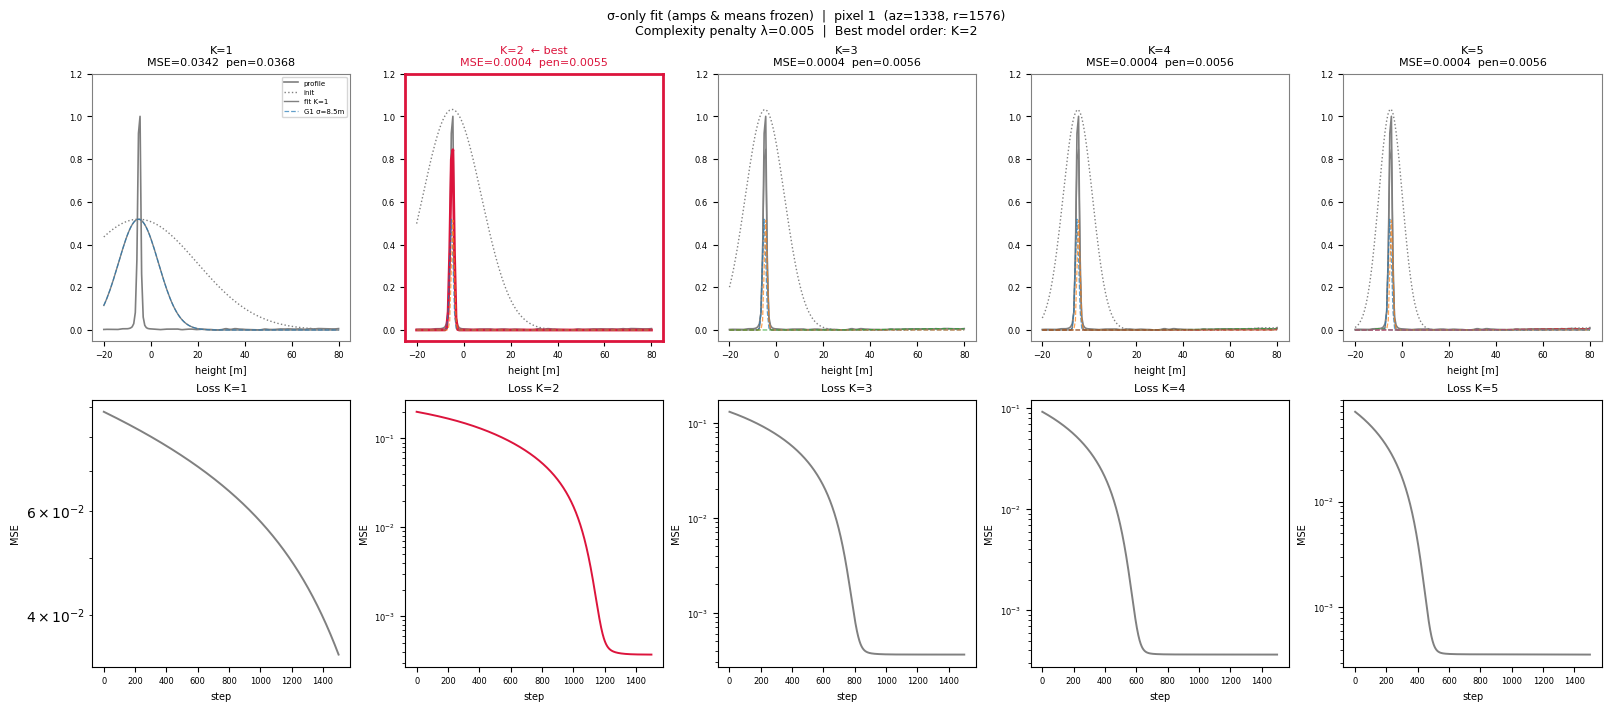


  K         MSE    pen_cost   penalised   best
----------------------------------------------
  1    0.034237    0.002593    0.036829
  2    0.000371    0.005164    0.005535 ◄
  3    0.000362    0.005196    0.005558
  4    0.000363    0.005226    0.005589
  5    0.000359    0.005260    0.005619

Final σ values for best K=2:
  G1: amp=0.0268  mu=-5.23m  sigma=0.70m
  G2: amp=0.0265  mu=-4.56m  sigma=0.61m


In [12]:
# ── Config ────────────────────────────────────────────────────────────────────
FREE_PIXEL_IDX = 0        # which sampled pixel to use
K_MAX          = 5        # maximum number of Gaussians to try
FREE_STEPS     = 1500     # Adam steps for each K
FREE_LR        = 1e-2     # learning rate (only σ moves)
LAMBDA_K       = 5e-3     # complexity penalty weight (larger → fewer components preferred)
# ─────────────────────────────────────────────────────────────────────────────

def adam_sigma_only(init_params, profile, h, n_steps, lr_max, lower, upper,
                    lambda_k=0.0, b1=B1, b2=B2, eps=EPS):
    """
    Adam optimiser where ONLY σ (every 3rd param starting at index 2) is free.
    Amplitudes and means are frozen to their init values throughout.
    An optional L1-style complexity penalty on the sum of amplitudes is added
    to the MSE loss to discourage unnecessary Gaussians.
    Returns final params, loss history, and the penalised final loss.
    """
    p        = np.clip(init_params.copy().astype(np.float64), lower, upper)
    amp_init = p[0::3].copy()
    mu_init  = p[1::3].copy()
    m        = np.zeros_like(p)
    v        = np.zeros_like(p)
    losses   = []
    n_g      = len(p) // 3

    for t in range(1, n_steps + 1):
        # forward + gradients (full, then mask)
        loss, g = mse_loss_and_grad(p, profile, h)
        # kill gradients for amps and means — only σ moves
        g[0::3] = 0.0
        g[1::3] = 0.0

        losses.append(loss)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        p = p - lr_max * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
        p = np.clip(p, lower, upper)
        # hard-freeze amps and means after every step
        p[0::3] = amp_init
        p[1::3] = mu_init

    # penalised loss = final MSE + lambda_k * K * mean_amp
    final_mse       = losses[-1]
    complexity_cost = lambda_k * n_g * float(np.mean(amp_init))
    penalised_loss  = final_mse + complexity_cost
    return p, np.array(losses), penalised_loss


# ── Setup ─────────────────────────────────────────────────────────────────────
res_free   = results[FREE_PIXEL_IDX]
profile_f  = res_free["raw"].astype(np.float64)
norm_f     = profile_f.max() if profile_f.max() > 1e-10 else 1.0
profile_fn = profile_f / norm_f
h64f       = height_axis.astype(np.float64)

# ── Sweep K ───────────────────────────────────────────────────────────────────
fit_results = {}   # K → dict(params, losses, pen_loss, init_p, lower, upper)

for K in range(1, K_MAX + 1):
    # Re-run prominence init for this K
    init_pK, _, _, _, _ = prominence_init(profile_f, height_axis, K, PROMINENCE_FRAC)
    init_pK = init_pK.astype(np.float64)
    # normalise amplitudes
    for g in range(K):
        init_pK[g*3] /= norm_f

    lowK, upK = build_bounds(height_axis, K)
    pK, lossK, penK = adam_sigma_only(
        init_pK, profile_fn, h64f, FREE_STEPS, FREE_LR, lowK, upK, lambda_k=LAMBDA_K
    )
    fit_results[K] = dict(params=pK, losses=lossK, pen_loss=penK,
                          init_p=init_pK, lower=lowK, upper=upK)
    print(f"K={K}  final MSE={lossK[-1]:.6f}  complexity_cost={LAMBDA_K*K*float(np.mean(init_pK[0::3])):.6f}  penalised={penK:.6f}")

best_K = min(fit_results, key=lambda k: fit_results[k]["pen_loss"])
print(f"\n→ Best K = {best_K}  (lowest penalised loss = {fit_results[best_K]['pen_loss']:.6f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols  = K_MAX
fig, axes = plt.subplots(2, ncols, figsize=(ncols * 3.2, 7), constrained_layout=True)

pen_losses = [fit_results[k]["pen_loss"] for k in range(1, K_MAX + 1)]
mse_losses = [fit_results[k]["losses"][-1] for k in range(1, K_MAX + 1)]

for col, K in enumerate(range(1, K_MAX + 1)):
    fr       = fit_results[K]
    pK       = fr["params"]
    init_pK  = fr["init_p"]
    lossK    = fr["losses"]
    is_best  = (K == best_K)
    border   = "crimson" if is_best else "grey"
    lw_prof  = 2.0 if is_best else 1.0

    # ── top row: profile + fit ────────────────────────────────────────────────
    ax_top = axes[0, col]
    ax_top.plot(h64f, profile_fn, color="black", lw=1.2, alpha=0.5, label="profile")
    # init mix (dashed)
    ax_top.plot(h64f, eval_gaussian_mix(h64f, init_pK, K),
                ":", color="grey", lw=1.0, label="init")
    # final mix
    pK_plot = pK.copy(); pK_plot[0::3] *= norm_f
    ax_top.plot(h64f, eval_gaussian_mix(h64f, pK_plot, K) / norm_f,
                color=border, lw=lw_prof, label=f"fit K={K}")
    # individual components
    for g in range(K):
        a, mu, sig = pK[g*3], pK[g*3+1], max(pK[g*3+2], 1e-6)
        comp = a * np.exp(-((h64f - mu)**2) / (2*sig**2))
        ax_top.plot(h64f, comp, lw=0.9, ls="--", color=COLORS[g % len(COLORS)],
                    alpha=0.7, label=f"G{g+1} σ={pK[g*3+2]:.1f}m")

    title_str = f"K={K}{'  ← best' if is_best else ''}\nMSE={lossK[-1]:.4f}  pen={fr['pen_loss']:.4f}"
    ax_top.set_title(title_str, fontsize=8, color=border if is_best else "black")
    ax_top.set_xlabel("height [m]", fontsize=7)
    ax_top.set_ylim(-0.05, 1.2)
    ax_top.tick_params(labelsize=6)
    if col == 0:
        ax_top.legend(fontsize=5, loc="upper right")
    for spine in ax_top.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(2.0 if is_best else 0.8)

    # ── bottom row: loss curve ────────────────────────────────────────────────
    ax_bot = axes[1, col]
    ax_bot.semilogy(lossK, color=border, lw=1.4)
    ax_bot.set_xlabel("step", fontsize=7); ax_bot.set_ylabel("MSE", fontsize=7)
    ax_bot.set_title(f"Loss K={K}", fontsize=8)
    ax_bot.tick_params(labelsize=6)

fig.suptitle(
    f"σ-only fit (amps & means frozen)  |  pixel {FREE_PIXEL_IDX+1}  "
    f"(az={res_free['az']}, r={res_free['r']})\n"
    f"Complexity penalty λ={LAMBDA_K}  |  Best model order: K={best_K}",
    fontsize=9
)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'K':>3}  {'MSE':>10}  {'pen_cost':>10}  {'penalised':>10}  {'best':>5}")
print("-" * 46)
for K in range(1, K_MAX + 1):
    fr = fit_results[K]
    cc = LAMBDA_K * K * float(np.mean(fr["init_p"][0::3]))
    marker = " ◄" if K == best_K else ""
    print(f"{K:>3}  {fr['losses'][-1]:>10.6f}  {cc:>10.6f}  {fr['pen_loss']:>10.6f}{marker}")

print(f"\nFinal σ values for best K={best_K}:")
pBest = fit_results[best_K]["params"]
for g in range(best_K):
    print(f"  G{g+1}: amp={pBest[g*3]*norm_f:.4f}  mu={pBest[g*3+1]:.2f}m  sigma={pBest[g*3+2]:.2f}m")


## 13 · Large-scale sweep — σ-only fit + model-order selection over many pixels


  50/5000  (35.9s)
  100/5000  (69.2s)
  150/5000  (99.5s)
  200/5000  (129.7s)
  250/5000  (160.0s)
  300/5000  (190.2s)
  350/5000  (220.4s)
  400/5000  (250.6s)
  450/5000  (280.5s)
  500/5000  (310.6s)
  550/5000  (340.9s)
  600/5000  (371.1s)
  650/5000  (401.4s)
  700/5000  (431.6s)
  750/5000  (461.8s)
  800/5000  (491.9s)
  850/5000  (522.0s)
  900/5000  (552.2s)
  950/5000  (582.3s)
  1000/5000  (612.5s)
  1050/5000  (642.6s)
  1100/5000  (672.7s)
  1150/5000  (702.8s)
  1200/5000  (733.0s)
  1250/5000  (763.1s)
  1300/5000  (793.2s)
  1350/5000  (823.3s)
  1400/5000  (853.6s)
  1450/5000  (883.7s)
  1500/5000  (913.7s)
  1550/5000  (943.8s)
  1600/5000  (973.9s)
  1650/5000  (1004.0s)
  1700/5000  (1034.0s)
  1750/5000  (1064.2s)
  1800/5000  (1094.5s)
  1850/5000  (1124.6s)
  1900/5000  (1154.9s)
  1950/5000  (1185.1s)
  2000/5000  (1215.2s)
  2050/5000  (1245.4s)
  2100/5000  (1275.4s)
  2150/5000  (1305.4s)
  2200/5000  (1335.5s)
  2250/5000  (1365.6s)
  2300/5000  (1395.7

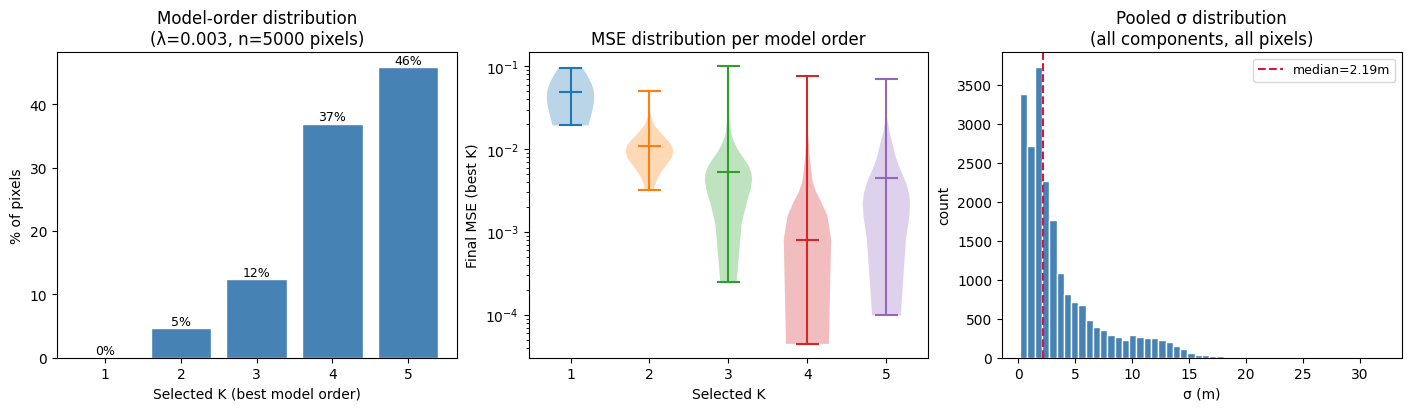

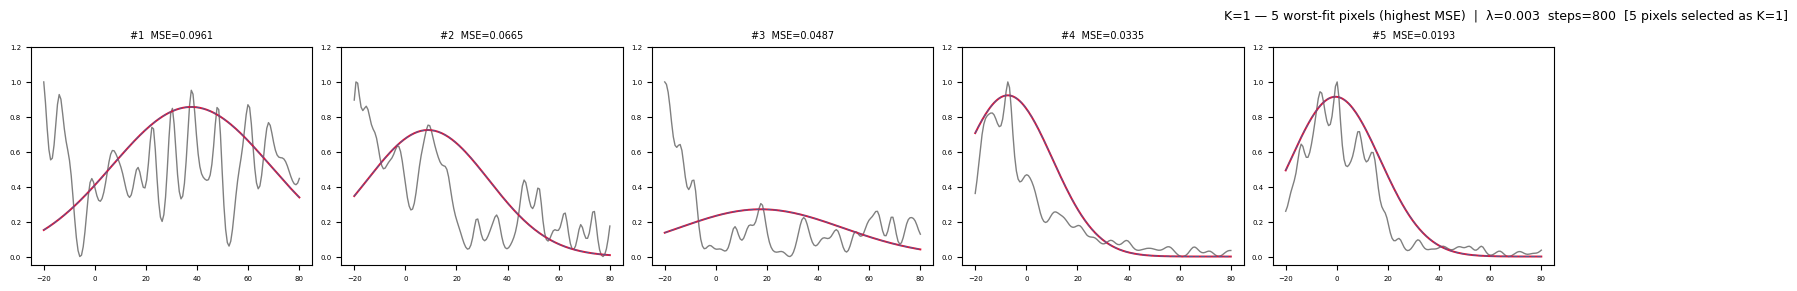

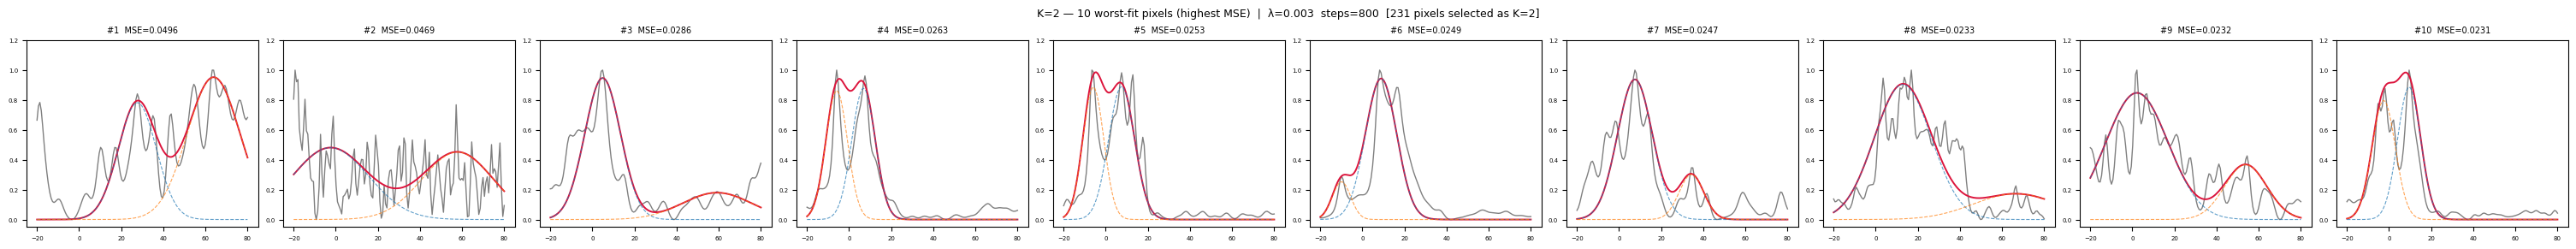

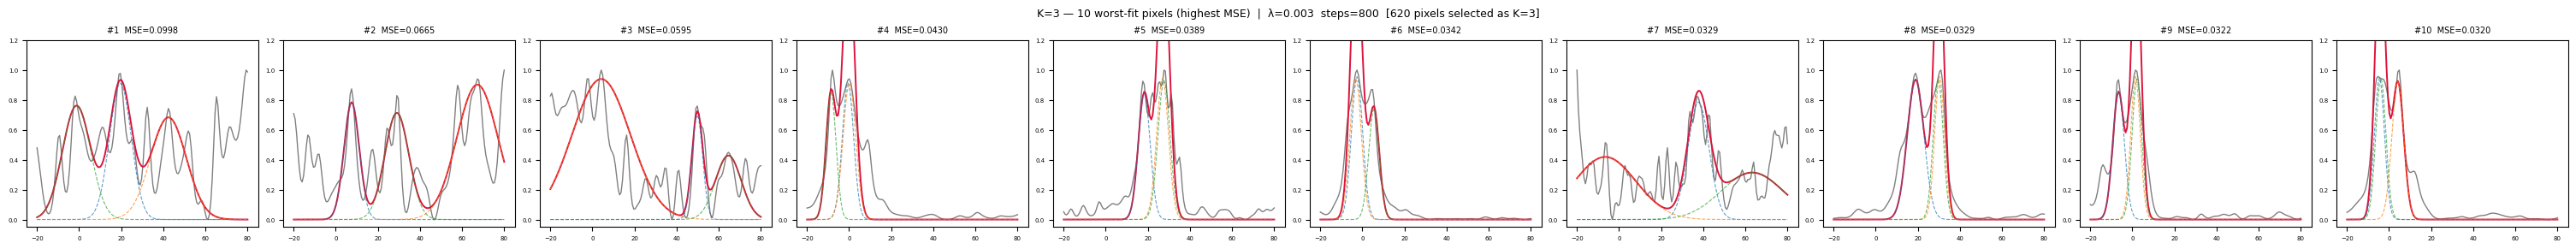

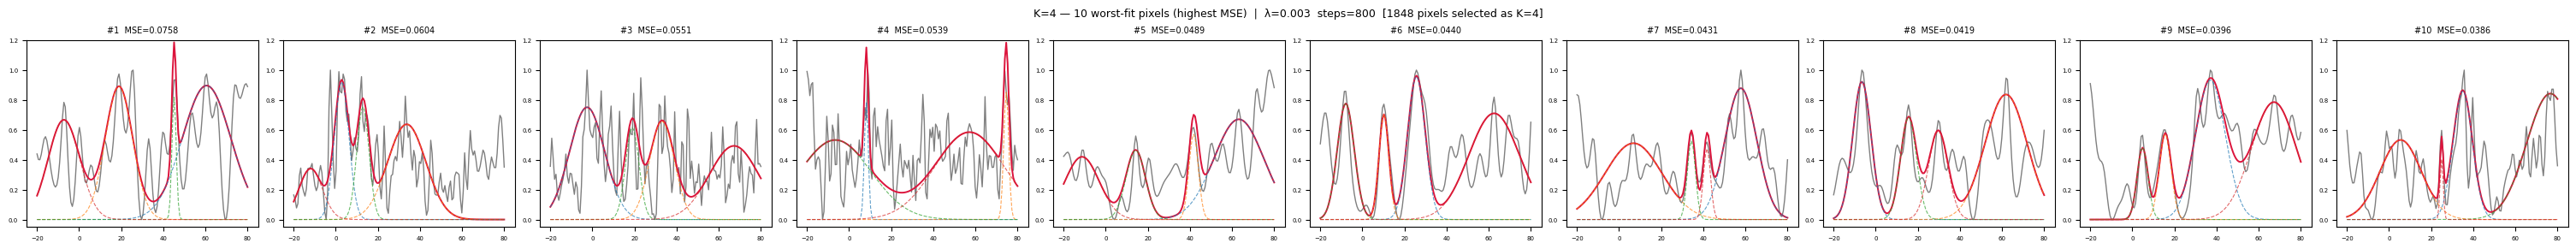

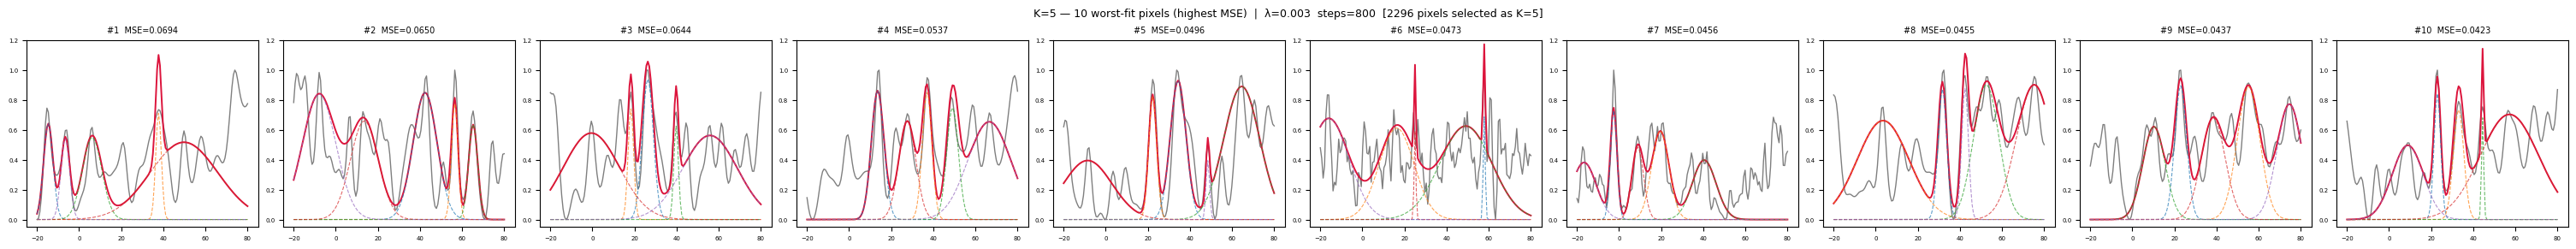

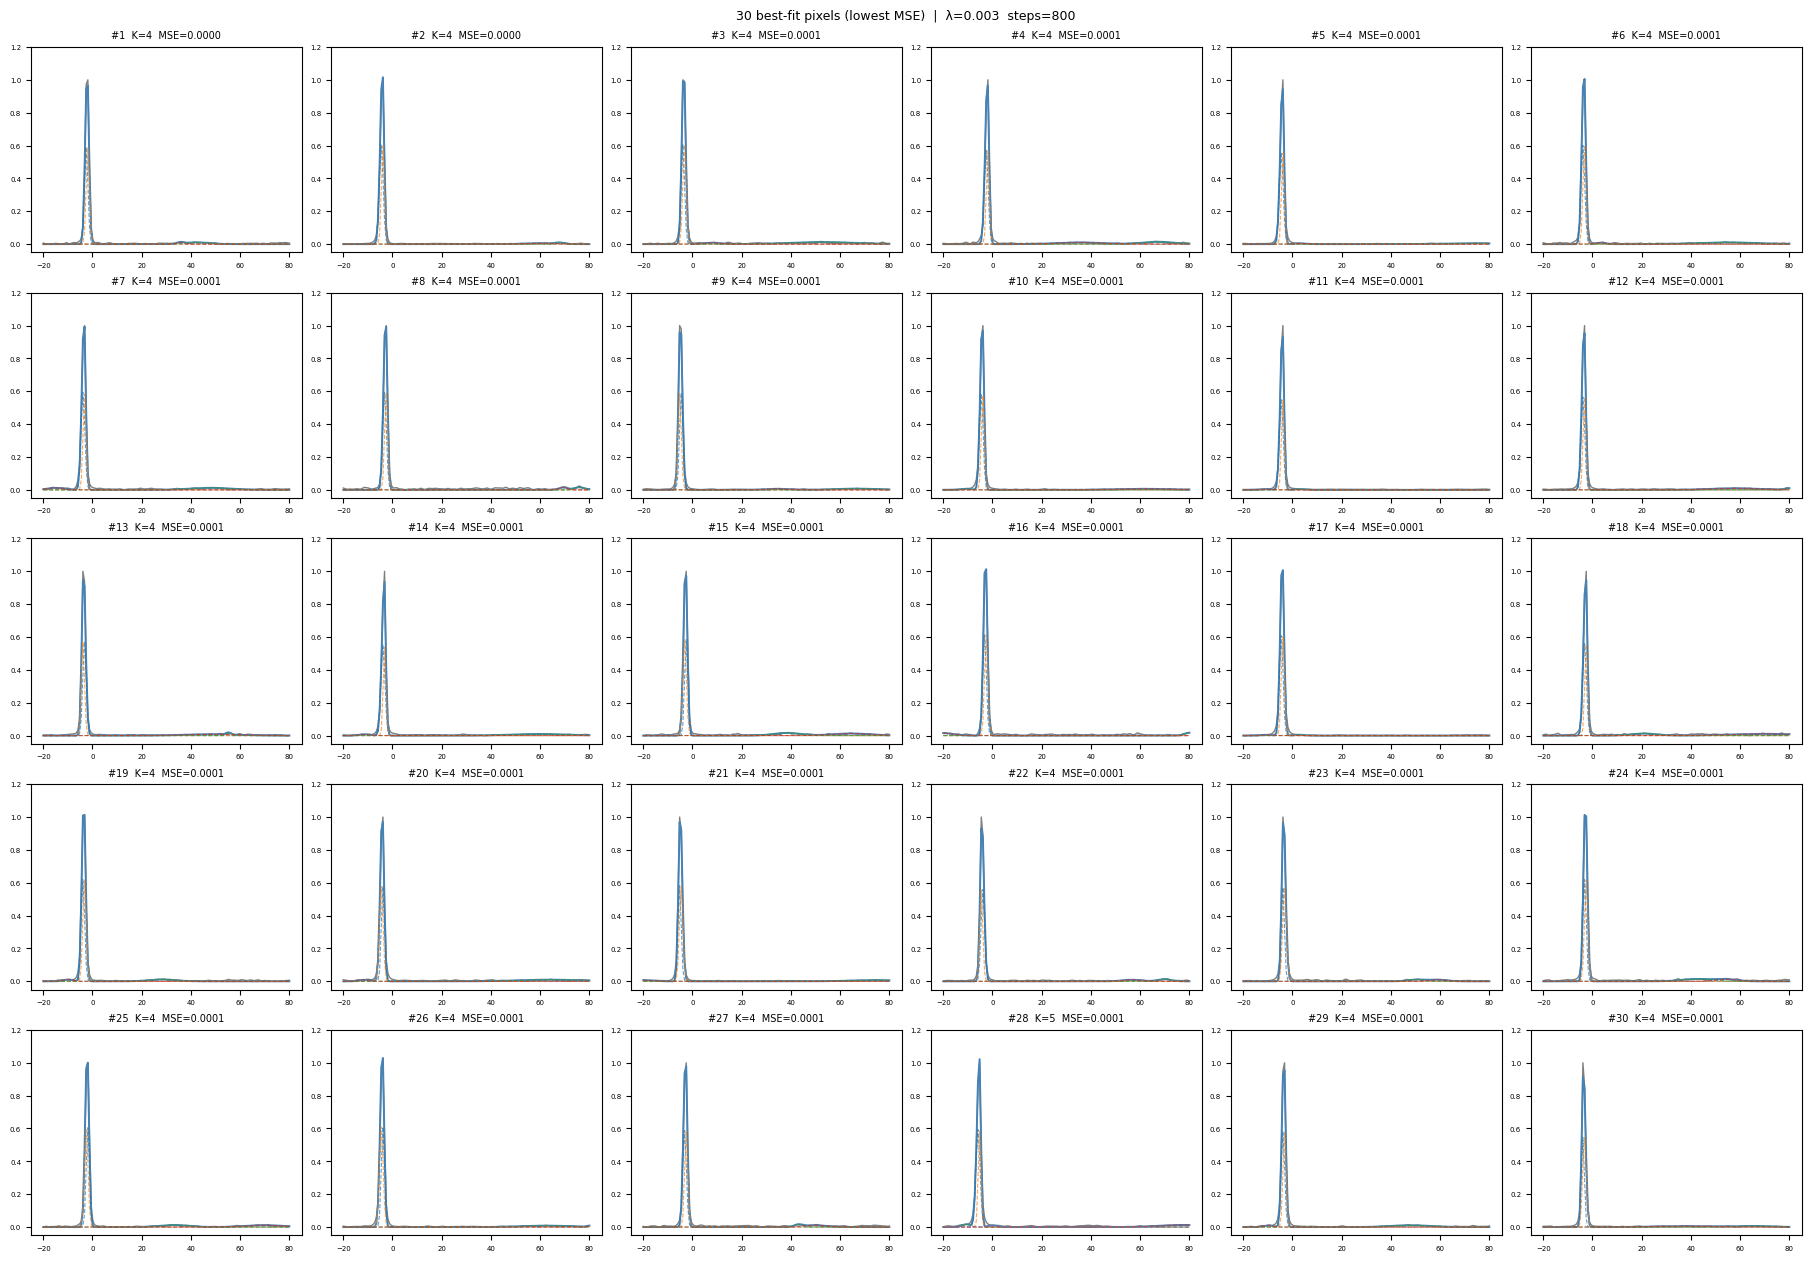

In [13]:

import time

# ── Config ─────────────────────────────────────────────────────────────────
N_SWEEP    = 5000    # number of random pixels to sweep
K_MAX_SW   = 5     # max Gaussians per pixel
STEPS_SW   = 800   # Adam steps per K (reduce for speed)
LR_SW      = 1e-2
LAMBDA_SW  = 3e-3  # complexity penalty
SEED_SW    = 123
N_WORST_PER_K = 10  # how many worst-fit pixels to show per K
# ───────────────────────────────────────────────────────────────────────────

rng_sw  = np.random.default_rng(SEED_SW)
az_sw   = rng_sw.integers(0, Az, N_SWEEP)
r_sw    = rng_sw.integers(0, R,  N_SWEEP)
h64sw   = height_axis.astype(np.float64)

sweep_best_K   = []          # best K per pixel
sweep_mse      = []          # MSE of best-K fit
sweep_sigmas   = []          # list of sigma arrays (length = best_K per pixel)
sweep_amps     = []          # list of amp arrays
sweep_mus      = []          # list of mu arrays
sweep_failed   = 0

t0 = time.time()
for idx_sw in range(N_SWEEP):
    prof_raw = np.abs(tomo[:, az_sw[idx_sw], r_sw[idx_sw]]).astype(np.float64)
    norm_sw  = prof_raw.max() if prof_raw.max() > 1e-10 else 1.0
    prof_n   = prof_raw / norm_sw

    best_pen  = np.inf
    best_K_sw = 1
    best_res  = None

    for K in range(1, K_MAX_SW + 1):
        try:
            init_pK, _, _, _, _ = prominence_init(prof_raw, height_axis, K, PROMINENCE_FRAC)
            init_pK = init_pK.astype(np.float64)
            init_pK[0::3] /= norm_sw
            lowK, upK = build_bounds(height_axis, K)
            pK, lossK, penK = adam_sigma_only(
                init_pK, prof_n, h64sw, STEPS_SW, LR_SW, lowK, upK, lambda_k=LAMBDA_SW
            )
            if penK < best_pen:
                best_pen  = penK
                best_K_sw = K
                best_res  = (pK, lossK[-1], norm_sw)
        except Exception:
            sweep_failed += 1

    if best_res is not None:
        pK_best, mse_best, nrm = best_res
        sweep_best_K.append(best_K_sw)
        sweep_mse.append(mse_best)
        sweep_sigmas.append(pK_best[2::3].copy())          # σ values
        sweep_amps.append(pK_best[0::3].copy() * nrm)     # un-normalised amps
        sweep_mus.append(pK_best[1::3].copy())             # μ values
    else:
        sweep_best_K.append(np.nan)
        sweep_mse.append(np.nan)
        sweep_sigmas.append(np.array([np.nan]))
        sweep_amps.append(np.array([np.nan]))
        sweep_mus.append(np.array([np.nan]))

    if (idx_sw + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f"  {idx_sw+1}/{N_SWEEP}  ({elapsed:.1f}s)")

elapsed = time.time() - t0
sweep_best_K = np.array(sweep_best_K, dtype=float)
sweep_mse    = np.array(sweep_mse,    dtype=float)
print(f"\nDone — {N_SWEEP} pixels in {elapsed:.1f}s  ({elapsed/N_SWEEP*1000:.0f} ms/pixel)  |  {sweep_failed} failures")
print(f"Best-K distribution: { {k: int((sweep_best_K==k).sum()) for k in range(1, K_MAX_SW+1)} }")
print(f"Median MSE (best K): {np.nanmedian(sweep_mse):.6f}")

# ── Figure 1: best-K distribution bar chart ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

k_vals, k_counts = np.unique(sweep_best_K[~np.isnan(sweep_best_K)].astype(int), return_counts=True)
bars = axes[0].bar(k_vals, k_counts / N_SWEEP * 100, color="steelblue", edgecolor="white")
axes[0].bar_label(bars, fmt="%.0f%%", fontsize=9)
axes[0].set_xlabel("Selected K (best model order)")
axes[0].set_ylabel("% of pixels")
axes[0].set_title(f"Model-order distribution\n(λ={LAMBDA_SW}, n={N_SWEEP} pixels)")

# ── Figure 2: MSE distribution per selected K ────────────────────────────────
for k in range(1, K_MAX_SW + 1):
    mask = sweep_best_K == k
    if mask.sum() > 0:
        axes[1].violinplot(sweep_mse[mask], positions=[k], showmedians=True, widths=0.6)
axes[1].set_xlabel("Selected K")
axes[1].set_ylabel("Final MSE (best K)")
axes[1].set_title("MSE distribution per model order")
axes[1].set_yscale("log")

# ── Figure 3: σ distribution across all pixels (all Gaussian components pooled) ──
all_sigmas = np.concatenate([s for s in sweep_sigmas if not np.all(np.isnan(s))])
axes[2].hist(all_sigmas[~np.isnan(all_sigmas)], bins=50, color="steelblue", edgecolor="white")
axes[2].set_xlabel("σ (m)")
axes[2].set_ylabel("count")
axes[2].set_title("Pooled σ distribution\n(all components, all pixels)")
axes[2].axvline(np.nanmedian(all_sigmas), color="crimson", lw=1.5, ls="--",
                label=f"median={np.nanmedian(all_sigmas):.2f}m")
axes[2].legend(fontsize=9)

plt.show()

# ── Figure 4: 10 worst-fit pixels PER K ──────────────────────────────────────
COLS_W = N_WORST_PER_K
valid_mask = ~np.isnan(sweep_mse)

for K_show in range(1, K_MAX_SW + 1):
    k_mask   = valid_mask & (sweep_best_K == K_show)
    k_idxs   = np.where(k_mask)[0]
    if len(k_idxs) == 0:
        print(f"K={K_show}: no pixels selected — skipping.")
        continue

    # sort by MSE descending, take top N_WORST_PER_K
    order       = np.argsort(sweep_mse[k_idxs])[::-1]
    worst_idxs  = k_idxs[order[:N_WORST_PER_K]]
    n_show      = len(worst_idxs)
    ROWS_W      = 1

    fig_k, axes_k = plt.subplots(ROWS_W, COLS_W, figsize=(COLS_W * 3, ROWS_W * 2.8),
                                  constrained_layout=True)
    axes_k = np.array(axes_k).reshape(-1)

    for plot_i, sw_i in enumerate(worst_idxs):
        ax = axes_k[plot_i]
        prof_raw = np.abs(tomo[:, az_sw[sw_i], r_sw[sw_i]]).astype(np.float64)
        norm_sw  = prof_raw.max() if prof_raw.max() > 1e-10 else 1.0
        prof_n   = prof_raw / norm_sw

        ax.plot(h64sw, prof_n, color="black", lw=1.0, alpha=0.5)

        init_pK, _, _, _, _ = prominence_init(prof_raw, height_axis, K_show, PROMINENCE_FRAC)
        init_pK = init_pK.astype(np.float64); init_pK[0::3] /= norm_sw
        lowK, upK = build_bounds(height_axis, K_show)
        pK_w, _, _ = adam_sigma_only(init_pK, prof_n, h64sw, STEPS_SW, LR_SW, lowK, upK, lambda_k=LAMBDA_SW)

        pK_plot = pK_w.copy(); pK_plot[0::3] *= norm_sw
        ax.plot(h64sw, eval_gaussian_mix(h64sw, pK_plot, K_show) / norm_sw,
                color="crimson", lw=1.4, label=f"K={K_show}")
        for g in range(K_show):
            a, mu_g, sig_g = pK_w[g*3], pK_w[g*3+1], max(pK_w[g*3+2], 1e-6)
            comp = a * np.exp(-((h64sw - mu_g)**2) / (2*sig_g**2))
            ax.plot(h64sw, comp, lw=0.8, ls="--", color=COLORS[g % len(COLORS)], alpha=0.7)

        ax.set_title(f"#{plot_i+1}  MSE={sweep_mse[sw_i]:.4f}", fontsize=7)
        ax.set_ylim(-0.05, 1.2); ax.tick_params(labelsize=5)

    for j in range(n_show, len(axes_k)):
        axes_k[j].set_visible(False)

    fig_k.suptitle(
        f"K={K_show} — {n_show} worst-fit pixels (highest MSE)  |  "
        f"λ={LAMBDA_SW}  steps={STEPS_SW}  "
        f"[{int(k_mask.sum())} pixels selected as K={K_show}]",
        fontsize=9
    )
    plt.show()

# ── Figure 5: grid of 30 best-fit pixels ─────────────────────────────────────
best_order = np.argsort(sweep_mse[valid_mask])
best_idxs  = np.where(valid_mask)[0][best_order[:30]]

ROWS_W_b = int(np.ceil(len(best_idxs) / 6))
fig3, axes3 = plt.subplots(ROWS_W_b, 6, figsize=(6 * 3, ROWS_W_b * 2.5), constrained_layout=True)
axes3 = np.array(axes3).reshape(-1)

for plot_i, sw_i in enumerate(best_idxs):
    ax = axes3[plot_i]
    prof_raw = np.abs(tomo[:, az_sw[sw_i], r_sw[sw_i]]).astype(np.float64)
    norm_sw  = prof_raw.max() if prof_raw.max() > 1e-10 else 1.0
    prof_n   = prof_raw / norm_sw
    K_best   = int(sweep_best_K[sw_i])

    ax.plot(h64sw, prof_n, color="black", lw=1.0, alpha=0.5)

    init_pK, _, _, _, _ = prominence_init(prof_raw, height_axis, K_best, PROMINENCE_FRAC)
    init_pK = init_pK.astype(np.float64); init_pK[0::3] /= norm_sw
    lowK, upK = build_bounds(height_axis, K_best)
    pK_b, _, _ = adam_sigma_only(init_pK, prof_n, h64sw, STEPS_SW, LR_SW, lowK, upK, lambda_k=LAMBDA_SW)

    pK_plot = pK_b.copy(); pK_plot[0::3] *= norm_sw
    ax.plot(h64sw, eval_gaussian_mix(h64sw, pK_plot, K_best) / norm_sw,
            color="steelblue", lw=1.4, label=f"K={K_best}")
    for g in range(K_best):
        a, mu_g, sig_g = pK_b[g*3], pK_b[g*3+1], max(pK_b[g*3+2], 1e-6)
        comp = a * np.exp(-((h64sw - mu_g)**2) / (2*sig_g**2))
        ax.plot(h64sw, comp, lw=0.8, ls="--", color=COLORS[g % len(COLORS)], alpha=0.7)

    ax.set_title(f"#{plot_i+1}  K={K_best}  MSE={sweep_mse[sw_i]:.4f}", fontsize=7)
    ax.set_ylim(-0.05, 1.2); ax.tick_params(labelsize=5)

for j in range(len(best_idxs), len(axes3)):
    axes3[j].set_visible(False)

fig3.suptitle(f"30 best-fit pixels (lowest MSE)  |  λ={LAMBDA_SW}  steps={STEPS_SW}", fontsize=9)
plt.show()


## 14 · R² audit — match the production `_estimate_r2` exactly

Compute R², normalised MSE, and denormalised MSE over the sweep pixels using **the same logic as `gpu_fitting_sigma_only.py`**, so you can directly compare notebook numbers to the pipeline output.


Pixels evaluated        : 5000  (0 skipped — below noise floor)
MSE (normalised)        : 0.03031
MSE (denormalised)      : 0.32408
R²  mean                : 0.3857
R²  median              : 0.5752
R²  std                 : 0.6477
R²  p10 / p25           : -0.3962  /  0.2365
R²  p75 / p90           : 0.7905  /  0.9014
R²  < 0  fraction       : 0.167

(threshold_factor=0.25  truncation_index=150  active_min_max=1e-07)


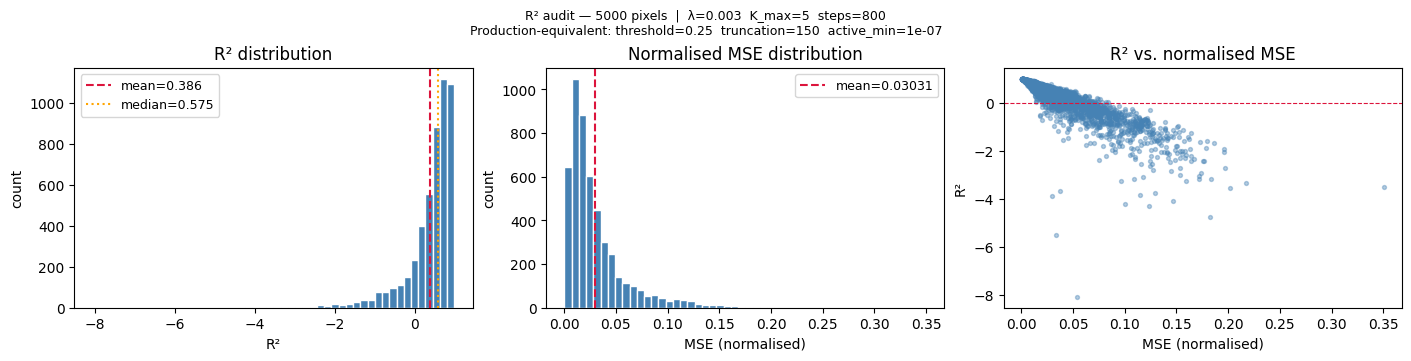

In [14]:

# ── Match these to what was used in the production run ────────────────────────
THRESHOLD_FACTOR  = 0.25   # same default as param_extraction_config.py
TRUNCATION_INDEX  = H      # H = no truncation (change if production used a crop)
ACTIVE_MIN_MAX    = 1e-7   # production: skip pixel if max(profile) <= this value
# ─────────────────────────────────────────────────────────────────────────────


def compute_r2_stats_production_equivalent(
    az_indices, r_indices, tomo,
    params_list, best_K_list, height_axis,
    threshold_factor=0.25, truncation_index=None, active_min_max=1e-7,
):
    """
    Mirrors gpu_fitting_sigma_only._estimate_r2 exactly, including:
      1. Per-pixel threshold zeroing  (bins < threshold_factor * pixel_max → 0)
      2. Truncation crop              (bins beyond truncation_index → 0)
      3. Active-pixel filter          (skip pixel if max <= active_min_max)
      4. safe_pmax guard on pmax      (avoid /0 on flat profiles)
      5. exp clipping                 (np.clip in exponent, prevents underflow)
      6. pred masking in ss_res       (pred_m = where(active_bins, pred, 0))
    """
    h   = height_axis.astype(np.float64)
    H   = len(h)
    if truncation_index is None:
        truncation_index = H

    mse_norm_list   = []
    mse_denorm_list = []
    r2_list         = []
    skipped         = 0

    for i, (az, r, params, K) in enumerate(
            zip(az_indices, r_indices, params_list, best_K_list)):

        # ── 1. Load raw profile ───────────────────────────────────────────────
        y = np.abs(tomo[:, az, r]).astype(np.float64)

        # ── 2. Threshold zeroing (per-pixel, same as _load_batch) ─────────────
        if threshold_factor > 0.0:
            y = np.where(y > y.max() * threshold_factor, y, 0.0)

        # ── 3. Truncation crop ────────────────────────────────────────────────
        if truncation_index < H:
            y = y.copy()
            y[truncation_index:] = 0.0

        # ── 4. Active-pixel filter ────────────────────────────────────────────
        if y.max() <= active_min_max:
            skipped += 1
            continue

        # ── 5. Reconstruct prediction (with exp clipping) ─────────────────────
        pred = np.zeros(H, dtype=np.float64)
        for g in range(K):
            a, mu, sig = params[g*3], params[g*3+1], max(params[g*3+2], 1e-6)
            exponent = np.clip(-((h - mu) ** 2) / (2 * sig ** 2 + 1e-10), -100.0, 0.0)
            pred += a * np.exp(exponent)

        active_bins = y > 0.0
        n_act       = max(active_bins.sum(), 1)

        # ── 6. Normalised MSE (safe pmax guard) ───────────────────────────────
        pmax     = y.max()
        safe_pmax = pmax if pmax > 1e-10 else 1.0
        y_n      = y    / safe_pmax
        pred_n   = pred / safe_pmax
        mse_norm_list.append((active_bins * (y_n - pred_n) ** 2).sum() / n_act)

        # ── 7. Denormalised MSE ───────────────────────────────────────────────
        mse_denorm_list.append((active_bins * (y - pred) ** 2).sum() / n_act)

        # ── 8. R² (pred masked before squaring, identical to production) ──────
        pred_m = np.where(active_bins, pred, 0.0)
        mean_y = (y * active_bins).sum() / n_act
        ss_res = (active_bins * (y - pred_m) ** 2).sum()
        ss_tot = (active_bins * (y - mean_y) ** 2).sum()
        if ss_tot > 1e-20:
            r2_list.append(1.0 - ss_res / ss_tot)

    return (
        np.array(mse_norm_list),
        np.array(mse_denorm_list),
        np.array(r2_list),
        skipped,
    )


# ── Build param arrays from sweep results ─────────────────────────────────────
az_audit    = []
r_audit     = []
param_audit = []
K_audit     = []

for i in range(N_SWEEP):
    if np.isnan(sweep_mse[i]):
        continue
    K = int(sweep_best_K[i])
    params = np.zeros(K * 3, dtype=np.float64)
    params[0::3] = sweep_amps[i][:K]
    params[1::3] = sweep_mus [i][:K]
    params[2::3] = sweep_sigmas[i][:K]
    az_audit.append(int(az_sw[i]))
    r_audit.append(int(r_sw[i]))
    param_audit.append(params)
    K_audit.append(K)

mse_norm_arr, mse_denorm_arr, r2_arr, n_skipped = compute_r2_stats_production_equivalent(
    az_audit, r_audit, tomo,
    param_audit, K_audit, height_axis,
    threshold_factor=THRESHOLD_FACTOR,
    truncation_index=TRUNCATION_INDEX,
    active_min_max=ACTIVE_MIN_MAX,
)

# ── Print (identical format to pipeline [RESULTS] section) ────────────────────
print(f"Pixels evaluated        : {len(r2_arr)}  ({n_skipped} skipped — below noise floor)")
print(f"MSE (normalised)        : {mse_norm_arr.mean():.5f}")
print(f"MSE (denormalised)      : {mse_denorm_arr.mean():.5f}")
print(f"R²  mean                : {r2_arr.mean():.4f}")
print(f"R²  median              : {np.median(r2_arr):.4f}")
print(f"R²  std                 : {r2_arr.std():.4f}")
print(f"R²  p10 / p25           : {np.percentile(r2_arr, 10):.4f}  /  {np.percentile(r2_arr, 25):.4f}")
print(f"R²  p75 / p90           : {np.percentile(r2_arr, 75):.4f}  /  {np.percentile(r2_arr, 90):.4f}")
print(f"R²  < 0  fraction       : {(r2_arr < 0).mean():.3f}")
print(f"\n(threshold_factor={THRESHOLD_FACTOR}  truncation_index={TRUNCATION_INDEX}  active_min_max={ACTIVE_MIN_MAX})")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)

axes[0].hist(r2_arr, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(r2_arr.mean(),     color="crimson", lw=1.5, ls="--", label=f"mean={r2_arr.mean():.3f}")
axes[0].axvline(np.median(r2_arr), color="orange",  lw=1.5, ls=":",  label=f"median={np.median(r2_arr):.3f}")
axes[0].set_xlabel("R²"); axes[0].set_ylabel("count")
axes[0].set_title("R² distribution"); axes[0].legend(fontsize=9)

axes[1].hist(mse_norm_arr, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(mse_norm_arr.mean(), color="crimson", lw=1.5, ls="--", label=f"mean={mse_norm_arr.mean():.5f}")
axes[1].set_xlabel("MSE (normalised)"); axes[1].set_ylabel("count")
axes[1].set_title("Normalised MSE distribution"); axes[1].legend(fontsize=9)

axes[2].scatter(mse_norm_arr, r2_arr, s=8, alpha=0.4, color="steelblue")
axes[2].set_xlabel("MSE (normalised)"); axes[2].set_ylabel("R²")
axes[2].set_title("R² vs. normalised MSE")
axes[2].axhline(0, color="crimson", lw=0.8, ls="--")

plt.suptitle(
    f"R² audit — {len(r2_arr)} pixels  |  λ={LAMBDA_SW}  K_max={K_MAX_SW}  steps={STEPS_SW}\n"
    f"Production-equivalent: threshold={THRESHOLD_FACTOR}  truncation={TRUNCATION_INDEX}  active_min={ACTIVE_MIN_MAX}",
    fontsize=9,
)
plt.show()


## 14 · Complexity penalty weight sweep — average MSE vs. λ

For each of 10 λ candidates, run the full σ-only fit + model-order selection over 300 random pixels and record the average best-K MSE. This reveals how the penalty weight trades off model fit quality against model complexity.

In [15]:
import time

# ── Config ─────────────────────────────────────────────────────────────────
LAMBDA_CANDIDATES = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2, 5e-2, 1e-1]
N_LAMBDA_SWEEP    = 300    # pixels per lambda
K_MAX_LS          = 5      # max Gaussians
STEPS_LS          = 800    # Adam steps per K
LR_LS             = 1e-2
SEED_LS           = 42
# ───────────────────────────────────────────────────────────────────────────

rng_ls = np.random.default_rng(SEED_LS)
az_ls  = rng_ls.integers(0, Az, N_LAMBDA_SWEEP)
r_ls   = rng_ls.integers(0, R,  N_LAMBDA_SWEEP)
h64ls  = height_axis.astype(np.float64)

# Pre-load all profiles once to keep things fair across lambdas
profiles_ls = [np.abs(tomo[:, az_ls[i], r_ls[i]]).astype(np.float64) for i in range(N_LAMBDA_SWEEP)]

lambda_results = {}   # lam → dict(mean_mse, std_mse, mean_K, mse_per_pixel)

t0 = time.time()
for lam in LAMBDA_CANDIDATES:
    mse_list  = []
    bestK_list = []

    for i, prof_raw in enumerate(profiles_ls):
        norm_ls = prof_raw.max() if prof_raw.max() > 1e-10 else 1.0
        prof_n  = prof_raw / norm_ls

        best_pen = np.inf
        best_mse = np.nan
        best_k   = 1

        for K in range(1, K_MAX_LS + 1):
            try:
                init_pK, _, _, _, _ = prominence_init(prof_raw, height_axis, K, PROMINENCE_FRAC)
                init_pK = init_pK.astype(np.float64)
                init_pK[0::3] /= norm_ls
                lowK, upK = build_bounds(height_axis, K)
                pK, lossK, penK = adam_sigma_only(
                    init_pK, prof_n, h64ls, STEPS_LS, LR_LS, lowK, upK, lambda_k=lam
                )
                if penK < best_pen:
                    best_pen = penK
                    best_mse = lossK[-1]
                    best_k   = K
            except Exception:
                pass

        mse_list.append(best_mse)
        bestK_list.append(best_k)

    mse_arr = np.array(mse_list, dtype=float)
    lambda_results[lam] = dict(
        mean_mse  = float(np.nanmean(mse_arr)),
        std_mse   = float(np.nanstd(mse_arr)),
        median_mse= float(np.nanmedian(mse_arr)),
        mean_K    = float(np.nanmean(bestK_list)),
        mse_arr   = mse_arr,
        K_arr     = np.array(bestK_list, dtype=float),
    )

elapsed = time.time() - t0
print(f"Done — {len(LAMBDA_CANDIDATES)} lambdas × {N_LAMBDA_SWEEP} pixels in {elapsed:.1f}s")
print(f"\n{'λ':>10}  {'mean MSE':>10}  {'median MSE':>12}  {'std MSE':>10}  {'mean K':>7}")
print("-" * 57)
for lam, r in lambda_results.items():
    print(f"{lam:>10.0e}  {r['mean_mse']:>10.6f}  {r['median_mse']:>12.6f}  {r['std_mse']:>10.6f}  {r['mean_K']:>7.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
lams       = np.array(LAMBDA_CANDIDATES)
mean_mses  = np.array([lambda_results[l]["mean_mse"]   for l in lams])
med_mses   = np.array([lambda_results[l]["median_mse"] for l in lams])
std_mses   = np.array([lambda_results[l]["std_mse"]    for l in lams])
mean_Ks    = np.array([lambda_results[l]["mean_K"]     for l in lams])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# left: mean ± std MSE vs λ
axes[0].errorbar(lams, mean_mses, yerr=std_mses, fmt="o-", color="steelblue",
                 lw=1.8, ms=6, capsize=4, label="mean ± std")
axes[0].plot(lams, med_mses, "s--", color="crimson", lw=1.4, ms=5, label="median")
axes[0].set_xscale("log")
axes[0].set_xlabel("complexity penalty λ")
axes[0].set_ylabel("MSE (best-K fit)")
axes[0].set_title(f"Average MSE vs. λ\n({N_LAMBDA_SWEEP} pixels, K_max={K_MAX_LS}, steps={STEPS_LS})")
axes[0].legend(fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)

# middle: mean selected K vs λ
axes[1].plot(lams, mean_Ks, "o-", color="darkorange", lw=1.8, ms=6)
axes[1].set_xscale("log")
axes[1].set_xlabel("complexity penalty λ")
axes[1].set_ylabel("mean selected K")
axes[1].set_title("Mean model order vs. λ")
axes[1].set_ylim(0.5, K_MAX_LS + 0.5)
axes[1].axhline(N_GAUSSIANS, color="grey", lw=1, ls="--", label=f"N_GAUSSIANS={N_GAUSSIANS}")
axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", alpha=0.3)

# right: violin of MSE distributions per λ (subsampled to keep readable)
positions = np.arange(len(lams))
vp = axes[2].violinplot(
    [lambda_results[l]["mse_arr"][~np.isnan(lambda_results[l]["mse_arr"])] for l in lams],
    positions=positions, showmedians=True, widths=0.7
)
axes[2].set_xticks(positions)
axes[2].set_xticklabels([f"{l:.0e}" for l in lams], rotation=45, fontsize=7)
axes[2].set_xlabel("λ")
axes[2].set_ylabel("MSE distribution")
axes[2].set_title("MSE distribution per λ")
axes[2].set_yscale("log")
axes[2].grid(True, axis="y", alpha=0.3)

plt.show()

# highlight best λ by lowest mean MSE
best_lam = lams[np.argmin(mean_mses)]
print(f"\n→ Best λ by mean MSE  : {best_lam:.0e}  (mean MSE = {lambda_results[best_lam]['mean_mse']:.6f})")
best_lam_med = lams[np.argmin(med_mses)]
print(f"→ Best λ by median MSE: {best_lam_med:.0e}  (median MSE = {lambda_results[best_lam_med]['median_mse']:.6f})")


KeyboardInterrupt: 

## 16 · Visual validation — production params vs. raw tomogram

Load `parameters_Ng3_sigonly_k5.npy` (shape `[15, Az, R]` = 5 Gaussians × [amp, μ, σ] per pixel) and reconstruct the Gaussian mixture for a random set of pixels, then overlay against the raw tomographic profile.


Params array : (15, 15000, 3500)  dtype=float32
Tomogram     : (150, 15000, 3500)  dtype=complex64


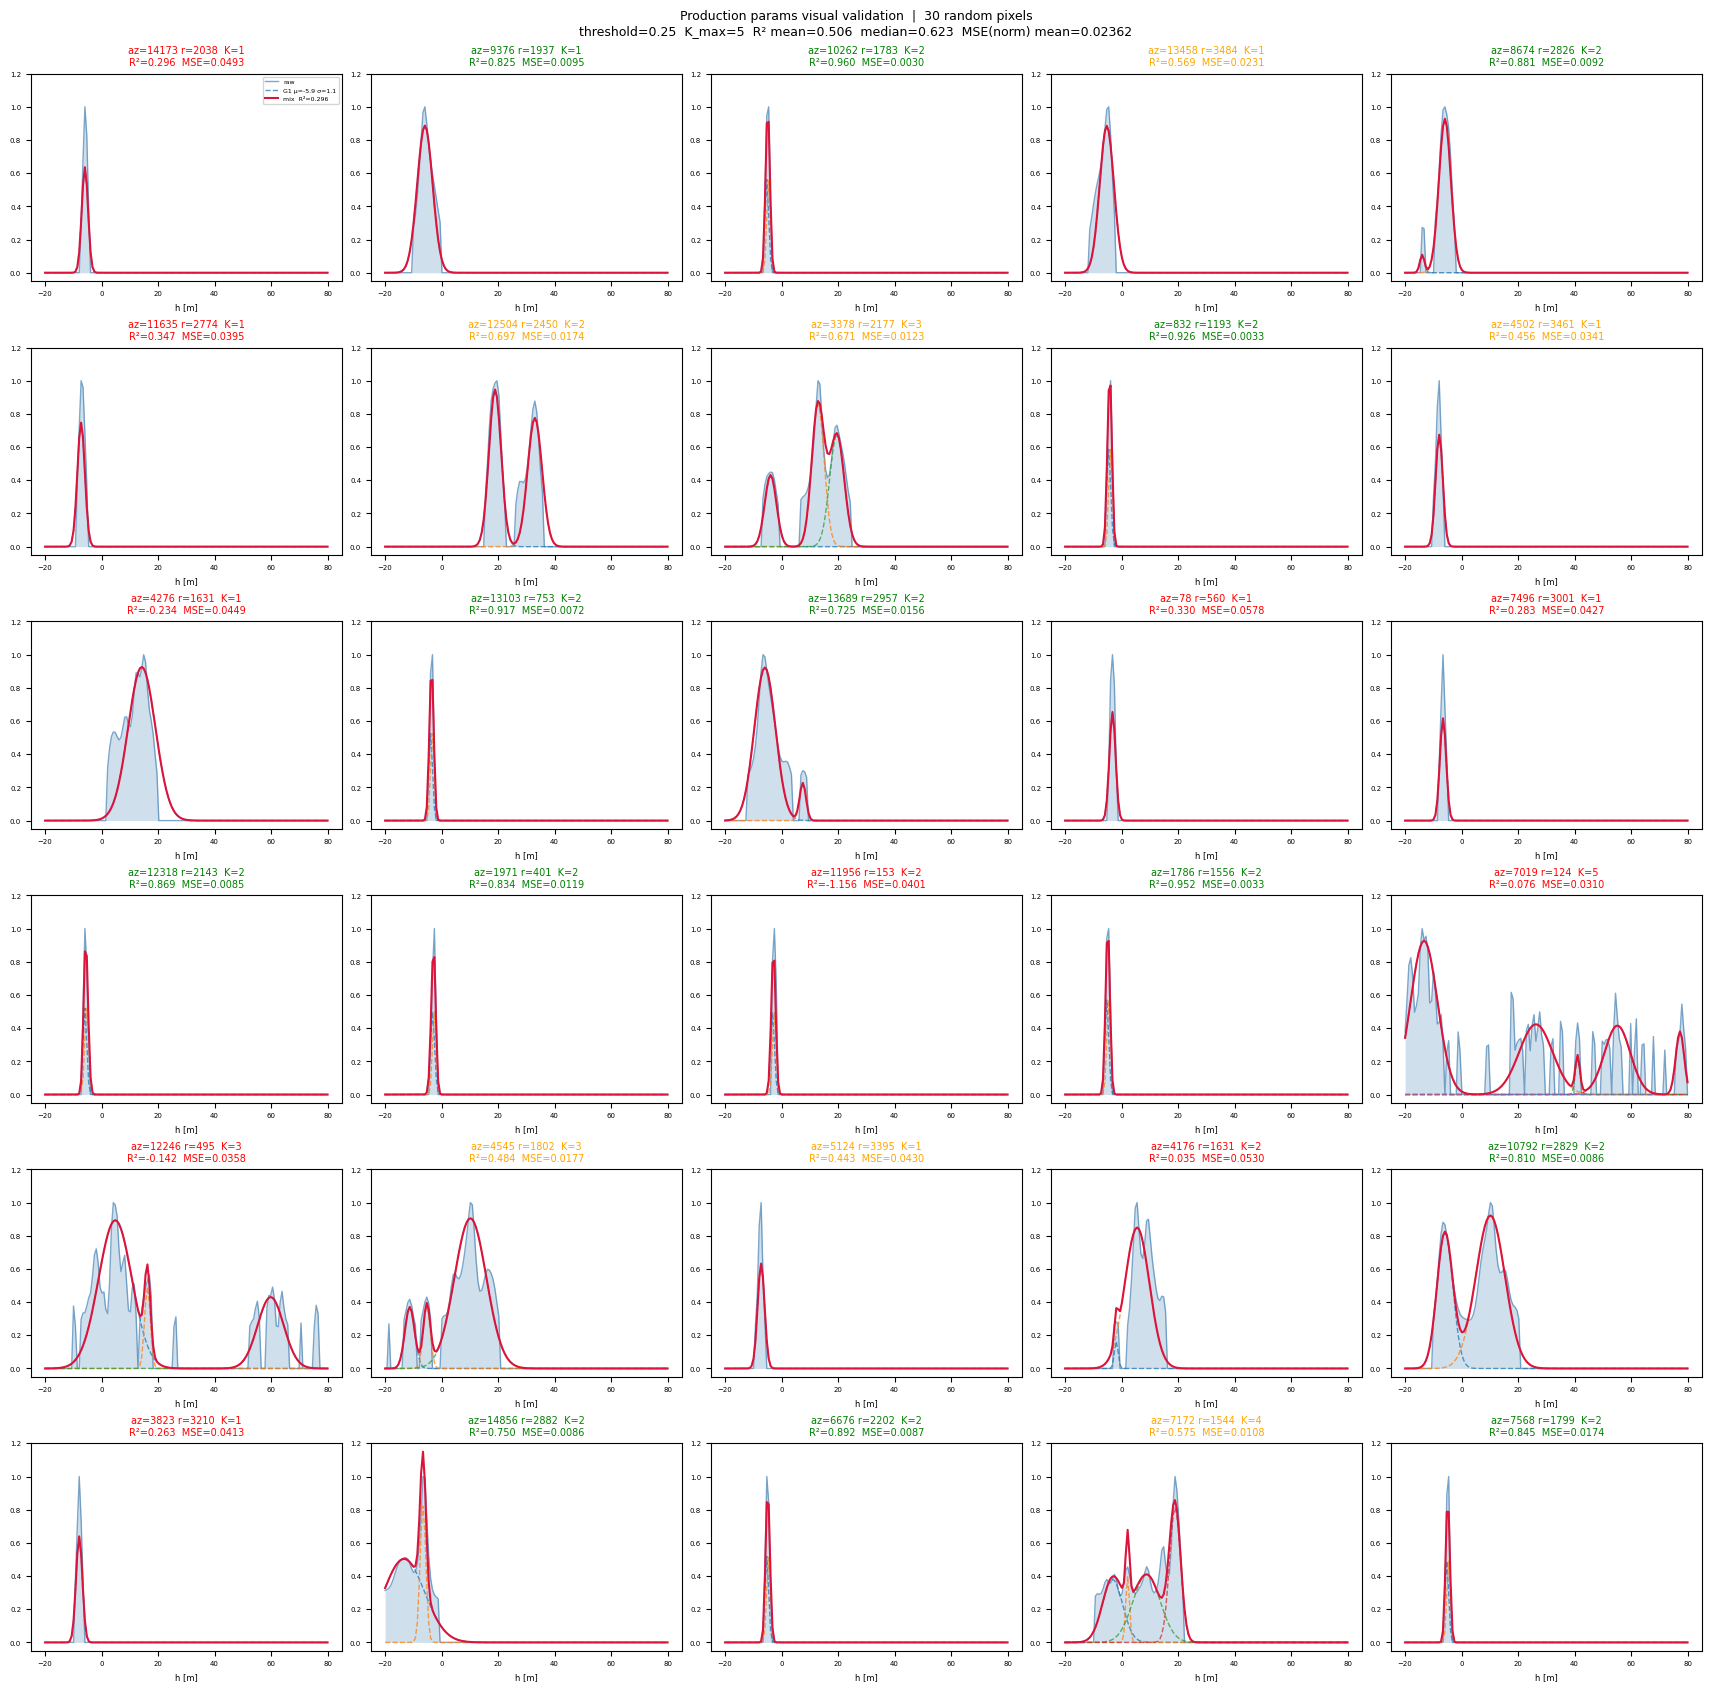


Aggregate over 30 pixels:
  R²   mean / median / std : 0.5060 / 0.6232 / 0.4517
  R²   p10 / p90           : 0.0173 / 0.9179
  MSE  (norm) mean         : 0.02362
  Best-K distribution      : {1: 10, 2: 15, 3: 3, 4: 1, 5: 1}


In [16]:

from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
PARAMS_PATH      = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset/params/"
                        "params_Ng3_sigonly_k5/parameters_Ng3_sigonly_k5.npy")
K_MAX_PROD       = 5          # Gaussians stored per pixel in the params file
THRESHOLD_PROD   = 0.25       # must match what was used in production
N_VAL            = 30         # pixels to visualise
SEED_VAL         = 7
COLS_VAL         = 5
# ─────────────────────────────────────────────────────────────────────────────

params_full = np.load(PARAMS_PATH, mmap_mode="r")   # (15, Az, R)
print(f"Params array : {params_full.shape}  dtype={params_full.dtype}")
print(f"Tomogram     : {tomo.shape}  dtype={tomo.dtype}")

# ── Random pixel sample ────────────────────────────────────────────────────────
rng_val  = np.random.default_rng(SEED_VAL)
Az_p, R_p = params_full.shape[1], params_full.shape[2]
az_val   = rng_val.integers(0, Az_p, N_VAL)
r_val    = rng_val.integers(0, R_p,  N_VAL)

# ── Reconstruct Gaussian mixture from stored params ──────────────────────────
def reconstruct_from_params(param_vec, h, K_max=5):
    """
    param_vec : (3*K_max,) float  — [amp0, mu0, sig0, amp1, ...]
    Returns pred (H,) and list of (amp, mu, sig) for active components.
    """
    pred       = np.zeros(len(h), dtype=np.float64)
    components = []
    for g in range(K_max):
        a, mu, sig = float(param_vec[g*3]), float(param_vec[g*3+1]), float(param_vec[g*3+2])
        if a == 0.0:          # zero-padded → inactive
            continue
        sig = max(sig, 1e-6)
        exponent = np.clip(-((h - mu) ** 2) / (2 * sig ** 2), -100.0, 0.0)
        comp = a * np.exp(exponent)
        pred += comp
        components.append((a, mu, sig, comp))
    return pred, components

# ── Layout ────────────────────────────────────────────────────────────────────
ROWS_VAL = int(np.ceil(N_VAL / COLS_VAL))
fig, axes = plt.subplots(ROWS_VAL, COLS_VAL,
                         figsize=(COLS_VAL * 3.4, ROWS_VAL * 2.8),
                         constrained_layout=True)
axes = np.array(axes).reshape(-1)

h64v    = height_axis.astype(np.float64)
r2_vals = []
mse_vals = []

for i in range(N_VAL):
    ax   = axes[i]
    az_i = int(az_val[i])
    r_i  = int(r_val[i])

    # ── raw profile with production threshold zeroing ─────────────────────────
    y_raw = np.abs(tomo[:, az_i, r_i]).astype(np.float64)
    if THRESHOLD_PROD > 0.0:
        y_raw = np.where(y_raw > y_raw.max() * THRESHOLD_PROD, y_raw, 0.0)

    pmax     = y_raw.max()
    safe_max = pmax if pmax > 1e-10 else 1.0
    y_n      = y_raw / safe_max

    # ── reconstruct from stored params ────────────────────────────────────────
    pvec = params_full[:, az_i, r_i].astype(np.float64)
    pred_raw, comps = reconstruct_from_params(pvec, h64v, K_MAX_PROD)
    pred_n  = pred_raw / safe_max
    K_active = len(comps)

    # ── per-pixel R² (active bins only) ───────────────────────────────────────
    active_bins = y_raw > 0.0
    n_act       = max(active_bins.sum(), 1)
    mean_y      = (y_raw * active_bins).sum() / n_act
    pred_m      = np.where(active_bins, pred_raw, 0.0)
    ss_res      = (active_bins * (y_raw - pred_m)  ** 2).sum()
    ss_tot      = (active_bins * (y_raw - mean_y)  ** 2).sum()
    r2          = (1.0 - ss_res / ss_tot) if ss_tot > 1e-20 else float("nan")
    mse_n       = (active_bins * (y_n - pred_n) ** 2).sum() / n_act

    if np.isfinite(r2):
        r2_vals.append(r2)
    mse_vals.append(mse_n)

    # ── plot ──────────────────────────────────────────────────────────────────
    ax.fill_between(h64v, 0, y_n, color="steelblue", alpha=0.25, lw=0)
    ax.plot(h64v, y_n, color="steelblue", lw=1.0, alpha=0.7, label="raw")

    for gi, (a, mu, sig, comp) in enumerate(comps):
        ax.plot(h64v, comp / safe_max,
                color=COLORS[gi % len(COLORS)], lw=1.0, ls="--", alpha=0.75,
                label=f"G{gi+1} μ={mu:.1f} σ={sig:.1f}")

    ax.plot(h64v, pred_n, color="crimson", lw=1.5,
            label=f"mix  R²={r2:.3f}" if np.isfinite(r2) else "mix")

    title_color = (
        "green"  if np.isfinite(r2) and r2 >= 0.7 else
        "orange" if np.isfinite(r2) and r2 >= 0.4 else
        "red"
    )
    ax.set_title(f"az={az_i} r={r_i}  K={K_active}\nR²={r2:.3f}  MSE={mse_n:.4f}",
                 fontsize=7, color=title_color)
    ax.set_xlabel("h [m]", fontsize=6)
    ax.set_ylim(-0.05, 1.2)
    ax.tick_params(labelsize=5)
    if i == 0:
        ax.legend(fontsize=4.5, loc="upper right")

for j in range(N_VAL, len(axes)):
    axes[j].set_visible(False)

r2_arr_v  = np.array(r2_vals)
mse_arr_v = np.array(mse_vals)

fig.suptitle(
    f"Production params visual validation  |  {N_VAL} random pixels\n"
    f"threshold={THRESHOLD_PROD}  K_max={K_MAX_PROD}  "
    f"R² mean={r2_arr_v.mean():.3f}  median={np.median(r2_arr_v):.3f}  "
    f"MSE(norm) mean={mse_arr_v.mean():.5f}",
    fontsize=9,
)
plt.show()

# ── Aggregate metrics ─────────────────────────────────────────────────────────
print(f"\nAggregate over {N_VAL} pixels:")
print(f"  R²   mean / median / std : {r2_arr_v.mean():.4f} / {np.median(r2_arr_v):.4f} / {r2_arr_v.std():.4f}")
print(f"  R²   p10 / p90           : {np.percentile(r2_arr_v,10):.4f} / {np.percentile(r2_arr_v,90):.4f}")
print(f"  MSE  (norm) mean         : {mse_arr_v.mean():.5f}")
k_counts_v = {k: int((np.array([len(reconstruct_from_params(
                    params_full[:, az_val[i], r_val[i]].astype(np.float64), h64v, K_MAX_PROD)[1])
               for i in range(N_VAL)]) == k).sum())
              for k in range(1, K_MAX_PROD + 1)}
print(f"  Best-K distribution      : {k_counts_v}")
